In [1]:
import sklearn
import numpy as np
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

In [2]:
def augment_data_Z2(data, shuffle=True, seed=0):
    # data: shape (num_samples, L)
    num_samples, L = data.shape
    augmented_data = np.zeros((num_samples*2, L))
    augmented_data[:num_samples, :] = data
    augmented_data[num_samples:, :] = - data  # Flip spins
    
    if shuffle:
        np.random.seed(seed)
        np.random.shuffle(augmented_data)
    
    return augmented_data

# Linear Regression

In [18]:
from snapshot_measurements import *
L = 100
seed = 0
sys_data = np.load("../data/Fast_CritIsing_L100_beta0.1_Zoutcomes_sys_1e6.npy")
anc_data = np.load("../data/Fast_CritIsing_L100_beta0.1_Zoutcomes_anc_1e6.npy")

L =  100
Estimated value at N->infinity for beta=0.01: 0.005559128346824206
Estimated value at N->infinity for beta=0.02: 0.019164289658211636
Estimated value at N->infinity for beta=0.05: 0.09464737338259062


Text(0.5, 0, '$N^{-1.00}$')

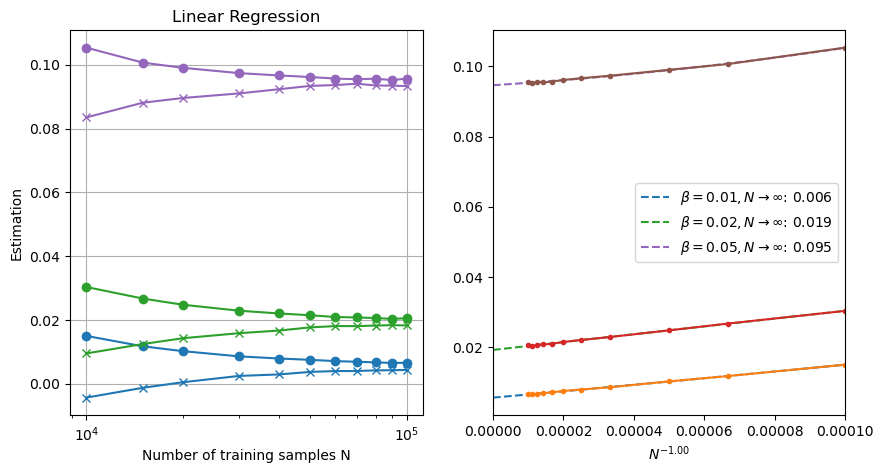

In [28]:
fig, axes = plt.subplots(1,2,figsize=(10,5))
seed = 0
N_list = [10000, 15000, 20000,30000, 40000, 50000, 60000, 70000, 80000, 90000,100000]
L = 100
print("L = ", L)
beta_list = [0.01, 0.02, 0.05]
Estimated_value_list = []
for beta in beta_list:
    sys_data = np.load(f"../data/Fast_CritIsing_L100_beta{beta}_Zoutcomes_sys_1e6.npy")
    anc_data = np.load(f"../data/Fast_CritIsing_L100_beta{beta}_Zoutcomes_anc_1e6.npy")
    sys_data = sys_data[:100000, :]
    anc_data = anc_data[:100000, :]
    sys_data = augment_data_Z2(sys_data, shuffle=True, seed=seed)
    anc_data = augment_data_Z2(anc_data, shuffle=True, seed=seed)
    np.random.seed(seed)
    indices = np.random.permutation(len(sys_data))

    A_list_train = []
    A_list_test = []
    for N in N_list:
        MSE_train_list = []
        MSE_test_list = []
        for i in range(L):
            X_train = anc_data[indices[:N]]
            y_train = sys_data[indices[:N], i]
            
            X_test = anc_data[indices[N:2*N]]
            y_test = sys_data[indices[N:2*N], i]
            
            my_model = LinearRegression(fit_intercept=False)
            my_model.fit(X_train, y_train)
            MSE_train = mean_squared_error(y_train, my_model.predict(X_train))
            MSE_train_list.append(MSE_train)
            MSE_test = mean_squared_error(y_test, my_model.predict(X_test))
            MSE_test_list.append(MSE_test)
        A_list_train.append(1-np.mean(MSE_train_list))
        A_list_test.append(1-np.mean(MSE_test_list))
    ax = axes[0]
    ax.plot(N_list, A_list_train, marker='o', label=f'L={L}')
    ax.plot(N_list, A_list_test, marker='x', label=f'L={L} (test)')
    ax.get_lines()[-1].set_color(ax.get_lines()[-2].get_color())


    ax = axes[1]
    y = np.array(A_list_train)
    x = np.array(N_list)
    powerlaw_exponent = 1.0
    x_ = 1/np.power(x,powerlaw_exponent)
    coefficients = np.polyfit(x_, y, 2)
    poly = np.poly1d(coefficients)
    x_fit = np.linspace(0, max(x_), 100)
    y_fit = poly(x_fit)
    ax.plot(x_fit, y_fit, '--', label=r'$\beta = %.2f, N\to\infty$: %.3f' % (beta, poly(0)))
    ax.plot(x_, y, '.-')
    Estimated_value_list.append(poly(0))
    print(f"Estimated value at N->infinity for beta={beta}: {poly(0)}")
 

ax = axes[0]
ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel('Number of training samples N')
ax.set_ylabel('Estimation')
ax.set_title('Linear Regression')
ax.grid(True)

ax = axes[1]
ax.set_xlim(0, max(x_))
ax.legend()

ax.set_xlabel(r'$N^{%.2f}$' % (-powerlaw_exponent))

L =  100
Estimated value at N->infinity for beta=0.1: 0.2281207838562934
Estimated value at N->infinity for beta=0.2: 0.3988533402166664
Estimated value at N->infinity for beta=0.3: 0.5173727211456798
Estimated value at N->infinity for beta=0.5: 0.6956842335295879
Estimated value at N->infinity for beta=0.8: 0.8703740641664097


Text(0.5, 0, '$N^{-1.00}$')

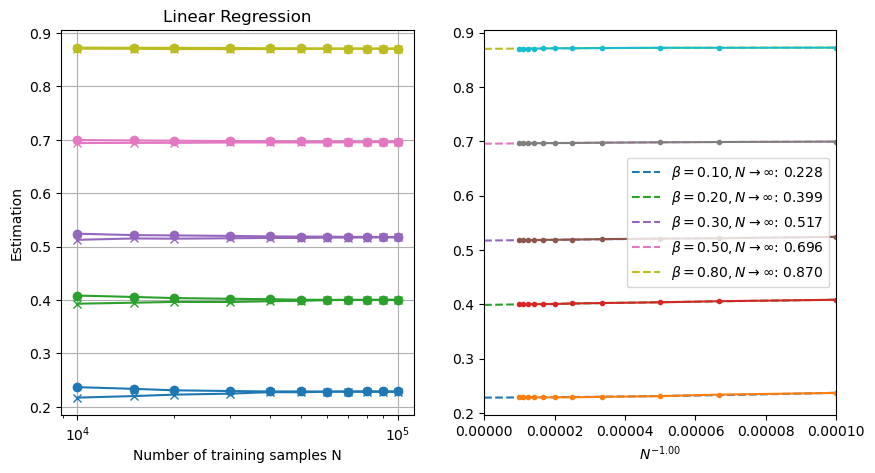

In [27]:
fig, axes = plt.subplots(1,2,figsize=(10,5))
seed = 0
N_list = [10000, 15000, 20000,30000, 40000, 50000, 60000, 70000, 80000, 90000,100000]
L = 100
print("L = ", L)
beta_list = [0.1, 0.2, 0.3, 0.5, 0.8]
Estimated_value_list = []
for beta in beta_list:
    sys_data = np.load(f"../data/Fast_CritIsing_L100_beta{beta}_Zoutcomes_sys.npy")
    anc_data = np.load(f"../data/Fast_CritIsing_L100_beta{beta}_Zoutcomes_anc.npy")
    sys_data = augment_data_Z2(sys_data, shuffle=True, seed=seed)
    anc_data = augment_data_Z2(anc_data, shuffle=True, seed=seed)
    np.random.seed(seed)
    indices = np.random.permutation(len(sys_data))

    A_list_train = []
    A_list_test = []
    for N in N_list:
        MSE_train_list = []
        MSE_test_list = []
        for i in range(L):
            X_train = anc_data[indices[:N]]
            y_train = sys_data[indices[:N], i]
            
            X_test = anc_data[indices[N:2*N]]
            y_test = sys_data[indices[N:2*N], i]
            
            my_model = LinearRegression(fit_intercept=False)
            my_model.fit(X_train, y_train)
            MSE_train = mean_squared_error(y_train, my_model.predict(X_train))
            MSE_train_list.append(MSE_train)
            MSE_test = mean_squared_error(y_test, my_model.predict(X_test))
            MSE_test_list.append(MSE_test)
        A_list_train.append(1-np.mean(MSE_train_list))
        A_list_test.append(1-np.mean(MSE_test_list))
    ax = axes[0]
    ax.plot(N_list, A_list_train, marker='o', label=f'L={L}')
    ax.plot(N_list, A_list_test, marker='x', label=f'L={L} (test)')
    ax.get_lines()[-1].set_color(ax.get_lines()[-2].get_color())


    ax = axes[1]
    y = np.array(A_list_train)
    x = np.array(N_list)
    powerlaw_exponent = 1.0
    x_ = 1/np.power(x,powerlaw_exponent)
    coefficients = np.polyfit(x_, y, 2)
    poly = np.poly1d(coefficients)
    x_fit = np.linspace(0, max(x_), 100)
    y_fit = poly(x_fit)
    ax.plot(x_fit, y_fit, '--', label=r'$\beta = %.2f, N\to\infty$: %.3f' % (beta, poly(0)))
    ax.plot(x_, y, '.-')
    Estimated_value_list.append(poly(0))
    print(f"Estimated value at N->infinity for beta={beta}: {poly(0)}")
 

ax = axes[0]
ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel('Number of training samples N')
ax.set_ylabel('Estimation')
ax.set_title('Linear Regression')
ax.grid(True)

ax = axes[1]
ax.set_xlim(0, max(x_))
ax.legend()

ax.set_xlabel(r'$N^{%.2f}$' % (-powerlaw_exponent))

L =  100
Estimated value at N->infinity for beta=1.0: 0.9345121407544664


Text(0.5, 0, '$N^{-1.00}$')

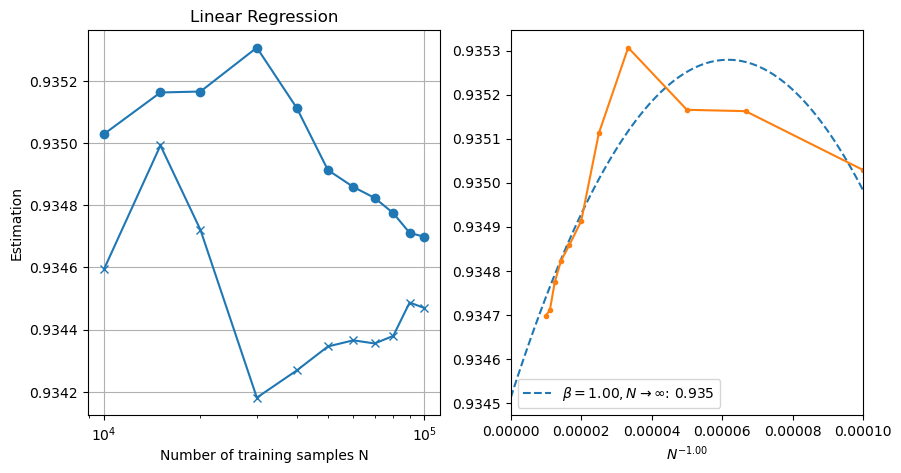

In [29]:
fig, axes = plt.subplots(1,2,figsize=(10,5))
seed = 0
N_list = [10000, 15000, 20000,30000, 40000, 50000, 60000, 70000, 80000, 90000,100000]
L = 100
print("L = ", L)
beta_list = [1.0]
Estimated_value_list = []
for beta in beta_list:
    sys_data = np.load(f"../data/Fast_CritIsing_L100_beta{beta}_Zoutcomes_sys.npy")
    anc_data = np.load(f"../data/Fast_CritIsing_L100_beta{beta}_Zoutcomes_anc.npy")
    sys_data = augment_data_Z2(sys_data, shuffle=True, seed=seed)
    anc_data = augment_data_Z2(anc_data, shuffle=True, seed=seed)
    np.random.seed(seed)
    indices = np.random.permutation(len(sys_data))

    A_list_train = []
    A_list_test = []
    for N in N_list:
        MSE_train_list = []
        MSE_test_list = []
        for i in range(L):
            X_train = anc_data[indices[:N]]
            y_train = sys_data[indices[:N], i]
            
            X_test = anc_data[indices[N:2*N]]
            y_test = sys_data[indices[N:2*N], i]
            
            my_model = LinearRegression(fit_intercept=False)
            my_model.fit(X_train, y_train)
            MSE_train = mean_squared_error(y_train, my_model.predict(X_train))
            MSE_train_list.append(MSE_train)
            MSE_test = mean_squared_error(y_test, my_model.predict(X_test))
            MSE_test_list.append(MSE_test)
        A_list_train.append(1-np.mean(MSE_train_list))
        A_list_test.append(1-np.mean(MSE_test_list))
    ax = axes[0]
    ax.plot(N_list, A_list_train, marker='o', label=f'L={L}')
    ax.plot(N_list, A_list_test, marker='x', label=f'L={L} (test)')
    ax.get_lines()[-1].set_color(ax.get_lines()[-2].get_color())


    ax = axes[1]
    y = np.array(A_list_train)
    x = np.array(N_list)
    powerlaw_exponent = 1.0
    x_ = 1/np.power(x,powerlaw_exponent)
    coefficients = np.polyfit(x_, y, 2)
    poly = np.poly1d(coefficients)
    x_fit = np.linspace(0, max(x_), 100)
    y_fit = poly(x_fit)
    ax.plot(x_fit, y_fit, '--', label=r'$\beta = %.2f, N\to\infty$: %.3f' % (beta, poly(0)))
    ax.plot(x_, y, '.-')
    Estimated_value_list.append(poly(0))
    print(f"Estimated value at N->infinity for beta={beta}: {poly(0)}")
 

ax = axes[0]
ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel('Number of training samples N')
ax.set_ylabel('Estimation')
ax.set_title('Linear Regression')
ax.grid(True)

ax = axes[1]
ax.set_xlim(0, max(x_))
ax.legend()

ax.set_xlabel(r'$N^{%.2f}$' % (-powerlaw_exponent))

In [39]:
beta_list = [0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.5, 0.8, 1.0]
estimated_values_100 = [0.005559128346824206, 0.019164289658211636, 0.09464737338259062, 0.228, 0.399, 0.517, 0.696, 0.870, 0.935]

L =  60
Estimated value at N->infinity for beta=0.01: 0.003950631940320227
Estimated value at N->infinity for beta=0.02: 0.014617955902568456
Estimated value at N->infinity for beta=0.05: 0.07802226945779941


Text(0.5, 0, '$N^{-1.00}$')

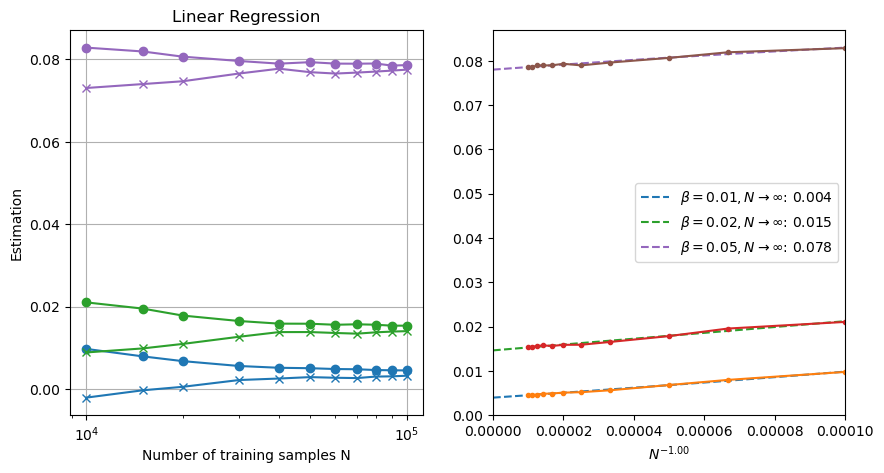

In [79]:
fig, axes = plt.subplots(1,2,figsize=(10,5))
seed = 0
N_list = [10000, 15000, 20000,30000, 40000, 50000, 60000, 70000, 80000, 90000,100000]
L = 60
print("L = ", L)
beta_list = [0.01, 0.02, 0.05]
Estimated_value_list = []
for beta in beta_list:
    sys_data = np.load(f"../data/Fast_CritIsing_L60_beta{beta}_Zoutcomes_sys_1e6.npy")
    anc_data = np.load(f"../data/Fast_CritIsing_L60_beta{beta}_Zoutcomes_anc_1e6.npy")
    sys_data = sys_data[:100000, :]
    anc_data = anc_data[:100000, :]
    sys_data = augment_data_Z2(sys_data, shuffle=True, seed=seed)
    anc_data = augment_data_Z2(anc_data, shuffle=True, seed=seed)
    np.random.seed(seed)
    indices = np.random.permutation(len(sys_data))

    A_list_train = []
    A_list_test = []
    for N in N_list:
        MSE_train_list = []
        MSE_test_list = []
        for i in range(L):
            X_train = anc_data[indices[:N]]
            y_train = sys_data[indices[:N], i]
            
            X_test = anc_data[indices[N:2*N]]
            y_test = sys_data[indices[N:2*N], i]
            
            my_model = LinearRegression(fit_intercept=False)
            my_model.fit(X_train, y_train)
            MSE_train = mean_squared_error(y_train, my_model.predict(X_train))
            MSE_train_list.append(MSE_train)
            MSE_test = mean_squared_error(y_test, my_model.predict(X_test))
            MSE_test_list.append(MSE_test)
        A_list_train.append(1-np.mean(MSE_train_list))
        A_list_test.append(1-np.mean(MSE_test_list))
    ax = axes[0]
    ax.plot(N_list, A_list_train, marker='o', label=f'L={L}')
    ax.plot(N_list, A_list_test, marker='x', label=f'L={L} (test)')
    ax.get_lines()[-1].set_color(ax.get_lines()[-2].get_color())


    ax = axes[1]
    y = np.array(A_list_train)
    x = np.array(N_list)
    powerlaw_exponent = 1.0
    x_ = 1/np.power(x,powerlaw_exponent)
    coefficients = np.polyfit(x_, y, 2)
    poly = np.poly1d(coefficients)
    x_fit = np.linspace(0, max(x_), 100)
    y_fit = poly(x_fit)
    ax.plot(x_fit, y_fit, '--', label=r'$\beta = %.2f, N\to\infty$: %.3f' % (beta, poly(0)))
    ax.plot(x_, y, '.-')
    Estimated_value_list.append(poly(0))
    print(f"Estimated value at N->infinity for beta={beta}: {poly(0)}")
 

ax = axes[0]
ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel('Number of training samples N')
ax.set_ylabel('Estimation')
ax.set_title('Linear Regression')
ax.grid(True)

ax = axes[1]
ax.set_xlim(0, max(x_))
ax.legend()

ax.set_xlabel(r'$N^{%.2f}$' % (-powerlaw_exponent))

L =  60
Estimated value at N->infinity for beta=0.1: 0.20979584236070975
Estimated value at N->infinity for beta=0.2: 0.39312927174133594
Estimated value at N->infinity for beta=0.3: 0.5160002082130213
Estimated value at N->infinity for beta=0.5: 0.6957446842837547
Estimated value at N->infinity for beta=0.8: 0.8709793742113915
Estimated value at N->infinity for beta=1.0: 0.935014787266971


Text(0.5, 0, '$N^{-1.00}$')

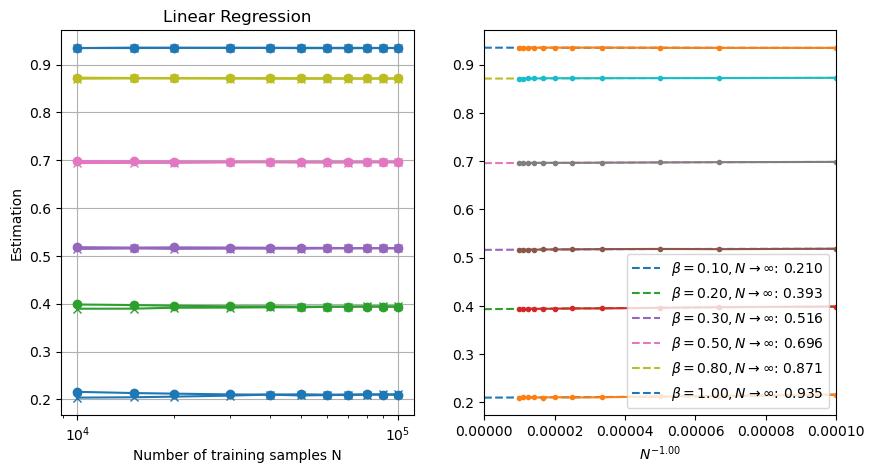

In [78]:
fig, axes = plt.subplots(1,2,figsize=(10,5))
seed = 0
N_list = [10000, 15000, 20000,30000, 40000, 50000, 60000, 70000, 80000, 90000,100000]
L = 60
print("L = ", L)
beta_list = [0.1, 0.2, 0.3, 0.5, 0.8, 1.0]
Estimated_value_list = []
for beta in beta_list:
    sys_data = np.load(f"../data/Fast_CritIsing_L60_beta{beta}_Zoutcomes_sys.npy")
    anc_data = np.load(f"../data/Fast_CritIsing_L60_beta{beta}_Zoutcomes_anc.npy")
    sys_data = augment_data_Z2(sys_data, shuffle=True, seed=seed)
    anc_data = augment_data_Z2(anc_data, shuffle=True, seed=seed)
    np.random.seed(seed)
    indices = np.random.permutation(len(sys_data))

    A_list_train = []
    A_list_test = []
    for N in N_list:
        MSE_train_list = []
        MSE_test_list = []
        for i in range(L):
            X_train = anc_data[indices[:N]]
            y_train = sys_data[indices[:N], i]
            
            X_test = anc_data[indices[N:2*N]]
            y_test = sys_data[indices[N:2*N], i]
            
            my_model = LinearRegression(fit_intercept=False)
            my_model.fit(X_train, y_train)
            MSE_train = mean_squared_error(y_train, my_model.predict(X_train))
            MSE_train_list.append(MSE_train)
            MSE_test = mean_squared_error(y_test, my_model.predict(X_test))
            MSE_test_list.append(MSE_test)
        A_list_train.append(1-np.mean(MSE_train_list))
        A_list_test.append(1-np.mean(MSE_test_list))
    ax = axes[0]
    ax.plot(N_list, A_list_train, marker='o', label=f'L={L}')
    ax.plot(N_list, A_list_test, marker='x', label=f'L={L} (test)')
    ax.get_lines()[-1].set_color(ax.get_lines()[-2].get_color())


    ax = axes[1]
    y = np.array(A_list_train)
    x = np.array(N_list)
    powerlaw_exponent = 1.0
    x_ = 1/np.power(x,powerlaw_exponent)
    coefficients = np.polyfit(x_, y, 2)
    poly = np.poly1d(coefficients)
    x_fit = np.linspace(0, max(x_), 100)
    y_fit = poly(x_fit)
    ax.plot(x_fit, y_fit, '--', label=r'$\beta = %.2f, N\to\infty$: %.3f' % (beta, poly(0)))
    ax.plot(x_, y, '.-')
    Estimated_value_list.append(poly(0))
    print(f"Estimated value at N->infinity for beta={beta}: {poly(0)}")
 

ax = axes[0]
ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel('Number of training samples N')
ax.set_ylabel('Estimation')
ax.set_title('Linear Regression')
ax.grid(True)

ax = axes[1]
ax.set_xlim(0, max(x_))
ax.legend()

ax.set_xlabel(r'$N^{%.2f}$' % (-powerlaw_exponent))

In [80]:
beta_list = [0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.5, 0.8, 1.0]
estimated_values_60 = [0.003950631940320227, 0.014617955902568456, 0.07802226945779941, 0.20979584236070975, 0.39312927174133594, 0.5160002082130213, 0.6957446842837547, 0.8709793742113915, 0.935014787266971]

L =  40
Estimated value at N->infinity for beta=0.01: 0.0030389497544991836
Estimated value at N->infinity for beta=0.02: 0.011728568540002468
Estimated value at N->infinity for beta=0.05: 0.06524118186628057


Text(0.5, 0, '$N^{-1.00}$')

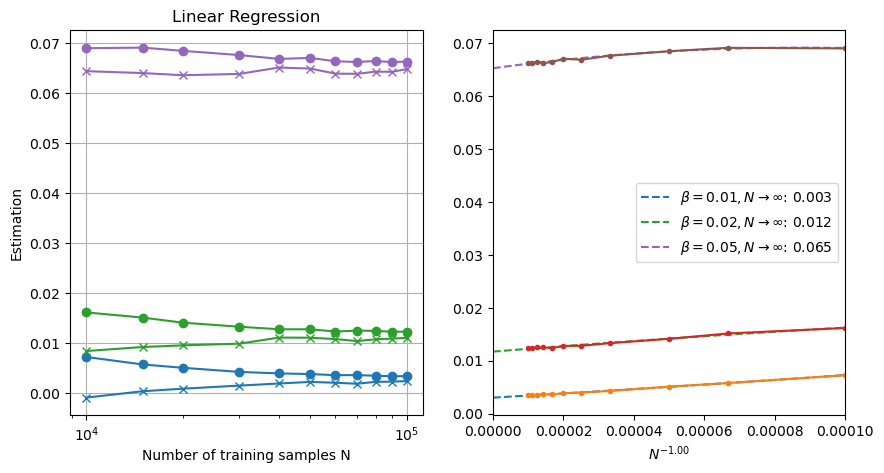

In [50]:
fig, axes = plt.subplots(1,2,figsize=(10,5))
seed = 0
N_list = [10000, 15000, 20000,30000, 40000, 50000, 60000, 70000, 80000, 90000,100000]
L = 40
print("L = ", L)
beta_list = [0.01, 0.02, 0.05]
Estimated_value_list = []
for beta in beta_list:
    sys_data = np.load(f"../data/Fast_CritIsing_L40_beta{beta}_Zoutcomes_sys_1e6.npy")
    anc_data = np.load(f"../data/Fast_CritIsing_L40_beta{beta}_Zoutcomes_anc_1e6.npy")
    sys_data = sys_data[:100000, :]
    anc_data = anc_data[:100000, :]
    sys_data = augment_data_Z2(sys_data, shuffle=True, seed=seed)
    anc_data = augment_data_Z2(anc_data, shuffle=True, seed=seed)
    np.random.seed(seed)
    indices = np.random.permutation(len(sys_data))

    A_list_train = []
    A_list_test = []
    for N in N_list:
        MSE_train_list = []
        MSE_test_list = []
        for i in range(L):
            X_train = anc_data[indices[:N]]
            y_train = sys_data[indices[:N], i]
            
            X_test = anc_data[indices[N:2*N]]
            y_test = sys_data[indices[N:2*N], i]
            
            my_model = LinearRegression(fit_intercept=False)
            my_model.fit(X_train, y_train)
            MSE_train = mean_squared_error(y_train, my_model.predict(X_train))
            MSE_train_list.append(MSE_train)
            MSE_test = mean_squared_error(y_test, my_model.predict(X_test))
            MSE_test_list.append(MSE_test)
        A_list_train.append(1-np.mean(MSE_train_list))
        A_list_test.append(1-np.mean(MSE_test_list))
    ax = axes[0]
    ax.plot(N_list, A_list_train, marker='o', label=f'L={L}')
    ax.plot(N_list, A_list_test, marker='x', label=f'L={L} (test)')
    ax.get_lines()[-1].set_color(ax.get_lines()[-2].get_color())


    ax = axes[1]
    y = np.array(A_list_train)
    x = np.array(N_list)
    powerlaw_exponent = 1.0
    x_ = 1/np.power(x,powerlaw_exponent)
    coefficients = np.polyfit(x_, y, 2)
    poly = np.poly1d(coefficients)
    x_fit = np.linspace(0, max(x_), 100)
    y_fit = poly(x_fit)
    ax.plot(x_fit, y_fit, '--', label=r'$\beta = %.2f, N\to\infty$: %.3f' % (beta, poly(0)))
    ax.plot(x_, y, '.-')
    Estimated_value_list.append(poly(0))
    print(f"Estimated value at N->infinity for beta={beta}: {poly(0)}")
 

ax = axes[0]
ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel('Number of training samples N')
ax.set_ylabel('Estimation')
ax.set_title('Linear Regression')
ax.grid(True)

ax = axes[1]
ax.set_xlim(0, max(x_))
ax.legend()

ax.set_xlabel(r'$N^{%.2f}$' % (-powerlaw_exponent))

L =  40
Estimated value at N->infinity for beta=0.1: 0.19158701551578944
Estimated value at N->infinity for beta=0.2: 0.38640363066769073
Estimated value at N->infinity for beta=0.3: 0.5131494359267623
Estimated value at N->infinity for beta=0.5: 0.6953368771523484
Estimated value at N->infinity for beta=0.8: 0.8707849560421619
Estimated value at N->infinity for beta=1.0: 0.9348204974496034


Text(0.5, 0, '$N^{-1.00}$')

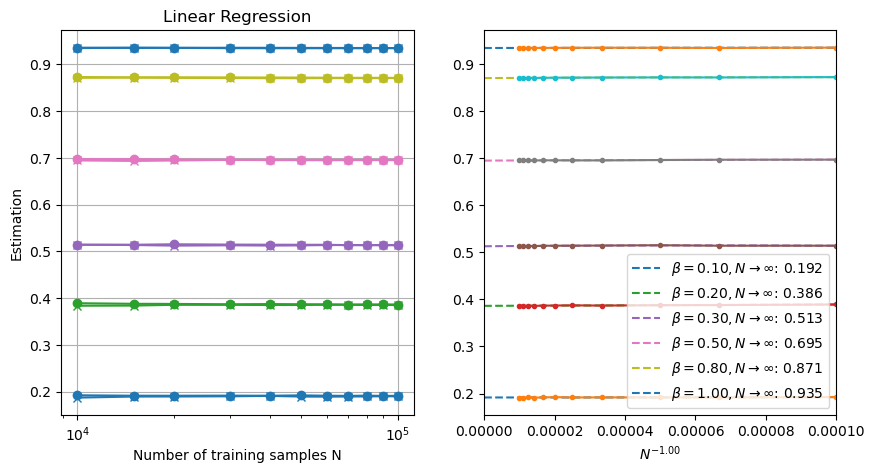

In [49]:
fig, axes = plt.subplots(1,2,figsize=(10,5))
seed = 0
N_list = [10000, 15000, 20000,30000, 40000, 50000, 60000, 70000, 80000, 90000,100000]
L = 40
print("L = ", L)
beta_list = [0.1, 0.2, 0.3, 0.5, 0.8, 1.0]
Estimated_value_list = []
for beta in beta_list:
    sys_data = np.load(f"../data/Fast_CritIsing_L40_beta{beta}_Zoutcomes_sys.npy")
    anc_data = np.load(f"../data/Fast_CritIsing_L40_beta{beta}_Zoutcomes_anc.npy")
    sys_data = augment_data_Z2(sys_data, shuffle=True, seed=seed)
    anc_data = augment_data_Z2(anc_data, shuffle=True, seed=seed)
    np.random.seed(seed)
    indices = np.random.permutation(len(sys_data))

    A_list_train = []
    A_list_test = []
    for N in N_list:
        MSE_train_list = []
        MSE_test_list = []
        for i in range(L):
            X_train = anc_data[indices[:N]]
            y_train = sys_data[indices[:N], i]
            
            X_test = anc_data[indices[N:2*N]]
            y_test = sys_data[indices[N:2*N], i]
            
            my_model = LinearRegression(fit_intercept=False)
            my_model.fit(X_train, y_train)
            MSE_train = mean_squared_error(y_train, my_model.predict(X_train))
            MSE_train_list.append(MSE_train)
            MSE_test = mean_squared_error(y_test, my_model.predict(X_test))
            MSE_test_list.append(MSE_test)
        A_list_train.append(1-np.mean(MSE_train_list))
        A_list_test.append(1-np.mean(MSE_test_list))
    ax = axes[0]
    ax.plot(N_list, A_list_train, marker='o', label=f'L={L}')
    ax.plot(N_list, A_list_test, marker='x', label=f'L={L} (test)')
    ax.get_lines()[-1].set_color(ax.get_lines()[-2].get_color())


    ax = axes[1]
    y = np.array(A_list_train)
    x = np.array(N_list)
    powerlaw_exponent = 1.0
    x_ = 1/np.power(x,powerlaw_exponent)
    coefficients = np.polyfit(x_, y, 2)
    poly = np.poly1d(coefficients)
    x_fit = np.linspace(0, max(x_), 100)
    y_fit = poly(x_fit)
    ax.plot(x_fit, y_fit, '--', label=r'$\beta = %.2f, N\to\infty$: %.3f' % (beta, poly(0)))
    ax.plot(x_, y, '.-')
    Estimated_value_list.append(poly(0))
    print(f"Estimated value at N->infinity for beta={beta}: {poly(0)}")
 

ax = axes[0]
ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel('Number of training samples N')
ax.set_ylabel('Estimation')
ax.set_title('Linear Regression')
ax.grid(True)

ax = axes[1]
ax.set_xlim(0, max(x_))
ax.legend()

ax.set_xlabel(r'$N^{%.2f}$' % (-powerlaw_exponent))

In [51]:
beta_list = [0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.5, 0.8, 1.0]
estimated_values_40 = [0.0030389497544991836, 0.011728568540002468, 0.06524118186628057, 0.19158701551578944, 0.38640363066769073, 0.5131494359267623, 0.6953368771523484, 0.8707849560421619, 0.9348204974496034]

L =  20
Estimated value at N->infinity for beta=0.01: 0.0021520917110003208
Estimated value at N->infinity for beta=0.02: 0.008275846115046863
Estimated value at N->infinity for beta=0.05: 0.048184135375001685


Text(0.5, 0, '$N^{-1.00}$')

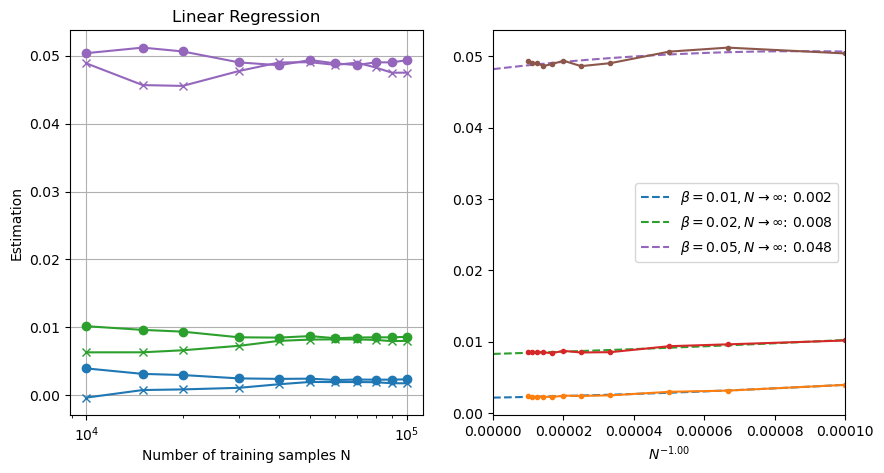

In [123]:
fig, axes = plt.subplots(1,2,figsize=(10,5))
seed = 0
N_list = [10000, 15000, 20000,30000, 40000, 50000, 60000, 70000, 80000, 90000,100000]
L = 20
print("L = ", L)
beta_list = [0.01, 0.02, 0.05]
Estimated_value_list = []
for beta in beta_list:
    sys_data = np.load(f"../data/Fast_CritIsing_L20_beta{beta}_Zoutcomes_sys.npy")
    anc_data = np.load(f"../data/Fast_CritIsing_L20_beta{beta}_Zoutcomes_anc.npy")
    sys_data = sys_data[:100000, :]
    anc_data = anc_data[:100000, :]
    sys_data = augment_data_Z2(sys_data, shuffle=True, seed=seed)
    anc_data = augment_data_Z2(anc_data, shuffle=True, seed=seed)
    np.random.seed(seed)
    indices = np.random.permutation(len(sys_data))

    A_list_train = []
    A_list_test = []
    for N in N_list:
        MSE_train_list = []
        MSE_test_list = []
        for i in range(L):
            X_train = anc_data[indices[:N]]
            y_train = sys_data[indices[:N], i]
            
            X_test = anc_data[indices[N:2*N]]
            y_test = sys_data[indices[N:2*N], i]
            
            my_model = LinearRegression(fit_intercept=False)
            my_model.fit(X_train, y_train)
            MSE_train = mean_squared_error(y_train, my_model.predict(X_train))
            MSE_train_list.append(MSE_train)
            MSE_test = mean_squared_error(y_test, my_model.predict(X_test))
            MSE_test_list.append(MSE_test)
        A_list_train.append(1-np.mean(MSE_train_list))
        A_list_test.append(1-np.mean(MSE_test_list))
    ax = axes[0]
    ax.plot(N_list, A_list_train, marker='o', label=f'L={L}')
    ax.plot(N_list, A_list_test, marker='x', label=f'L={L} (test)')
    ax.get_lines()[-1].set_color(ax.get_lines()[-2].get_color())


    ax = axes[1]
    y = np.array(A_list_train)
    x = np.array(N_list)
    powerlaw_exponent = 1.0
    x_ = 1/np.power(x,powerlaw_exponent)
    coefficients = np.polyfit(x_, y, 2)
    poly = np.poly1d(coefficients)
    x_fit = np.linspace(0, max(x_), 100)
    y_fit = poly(x_fit)
    ax.plot(x_fit, y_fit, '--', label=r'$\beta = %.2f, N\to\infty$: %.3f' % (beta, poly(0)))
    ax.plot(x_, y, '.-')
    Estimated_value_list.append(poly(0))
    print(f"Estimated value at N->infinity for beta={beta}: {poly(0)}")
 

ax = axes[0]
ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel('Number of training samples N')
ax.set_ylabel('Estimation')
ax.set_title('Linear Regression')
ax.grid(True)

ax = axes[1]
ax.set_xlim(0, max(x_))
ax.legend()

ax.set_xlabel(r'$N^{%.2f}$' % (-powerlaw_exponent))

L =  20
Estimated value at N->infinity for beta=0.1: 0.15739607997394073
Estimated value at N->infinity for beta=0.2: 0.3645696782482053
Estimated value at N->infinity for beta=0.3: 0.5061185598899618
Estimated value at N->infinity for beta=0.5: 0.6948145136603397
Estimated value at N->infinity for beta=0.8: 0.8702783263245539
Estimated value at N->infinity for beta=1.0: 0.9348546788442901


Text(0.5, 0, '$N^{-1.00}$')

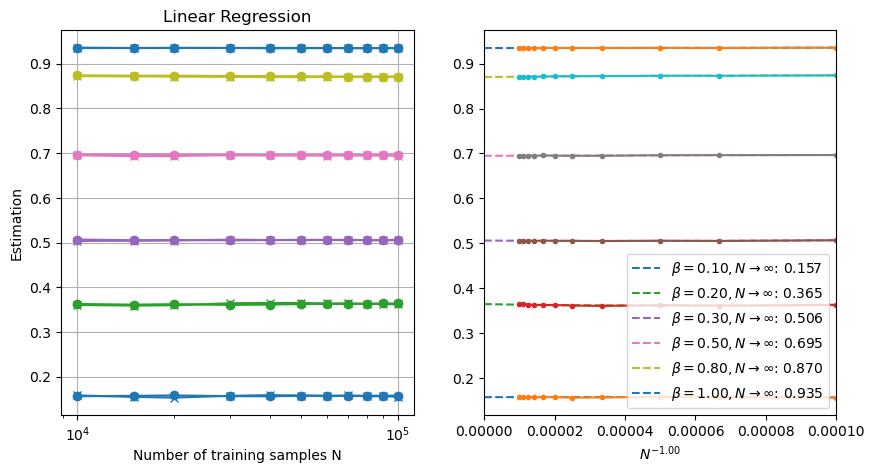

In [ ]:
fig, axes = plt.subplots(1,2,figsize=(10,5))
seed = 0
N_list = [10000, 15000, 20000,30000, 40000, 50000, 60000, 70000, 80000, 90000,100000]
L = 20
print("L = ", L)
beta_list = [0.1, 0.2, 0.3, 0.5, 0.8, 1.0]
Estimated_value_list = []
for beta in beta_list:
    sys_data = np.load(f"../data/Fast_CritIsing_L20_beta{beta}_Zoutcomes_sys.npy")
    anc_data = np.load(f"../data/Fast_CritIsing_L20_beta{beta}_Zoutcomes_anc.npy")
    sys_data = augment_data_Z2(sys_data, shuffle=True, seed=seed)
    anc_data = augment_data_Z2(anc_data, shuffle=True, seed=seed)
    np.random.seed(seed)
    indices = np.random.permutation(len(sys_data))

    A_list_train = []
    A_list_test = []
    for N in N_list:
        MSE_train_list = []
        MSE_test_list = []
        for i in range(L):
            X_train = anc_data[indices[:N]]
            y_train = sys_data[indices[:N], i]
            
            X_test = anc_data[indices[N:2*N]]
            y_test = sys_data[indices[N:2*N], i]
            
            my_model = LinearRegression(fit_intercept=False)
            my_model.fit(X_train, y_train)
            MSE_train = mean_squared_error(y_train, my_model.predict(X_train))
            MSE_train_list.append(MSE_train)
            MSE_test = mean_squared_error(y_test, my_model.predict(X_test))
            MSE_test_list.append(MSE_test)
        A_list_train.append(1-np.mean(MSE_train_list))
        A_list_test.append(1-np.mean(MSE_test_list))
    ax = axes[0]
    ax.plot(N_list, A_list_train, marker='o', label=f'L={L}')
    ax.plot(N_list, A_list_test, marker='x', label=f'L={L} (test)')
    ax.get_lines()[-1].set_color(ax.get_lines()[-2].get_color())


    ax = axes[1]
    y = np.array(A_list_train)
    x = np.array(N_list)
    powerlaw_exponent = 1.0
    x_ = 1/np.power(x,powerlaw_exponent)
    coefficients = np.polyfit(x_, y, 2)
    poly = np.poly1d(coefficients)
    x_fit = np.linspace(0, max(x_), 100)
    y_fit = poly(x_fit)
    ax.plot(x_fit, y_fit, '--', label=r'$\beta = %.2f, N\to\infty$: %.3f' % (beta, poly(0)))
    ax.plot(x_, y, '.-')
    Estimated_value_list.append(poly(0))
    print(f"Estimated value at N->infinity for beta={beta}: {poly(0)}")
 

ax = axes[0]
ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel('Number of training samples N')
ax.set_ylabel('Estimation')
ax.set_title('Linear Regression')
ax.grid(True)

ax = axes[1]
ax.set_xlim(0, max(x_))
ax.legend()

ax.set_xlabel(r'$N^{%.2f}$' % (-powerlaw_exponent))

In [124]:
beta_list = [0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.5, 0.8, 1.0]
estimated_values_20 = [0.0021520917110003208, 0.008275846115046863, 0.048184135375001685, 0.15739607997394073, 0.3645696782482053, 0.5061185598899618, 0.6948145136603397, 0.8702783263245539, 0.9348546788442901]

(0.001, 2.0)

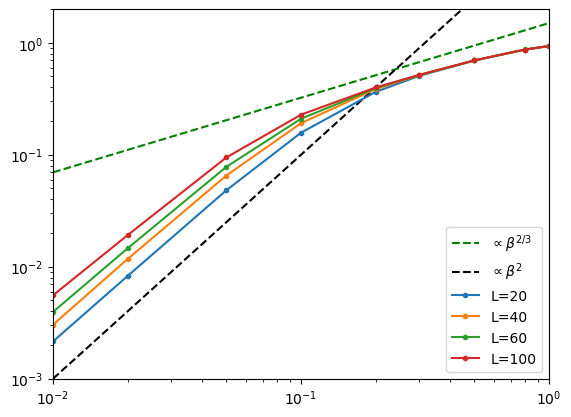

In [125]:
x = np.array(beta_list)
plt.xscale('log')
plt.yscale('log')
plt.plot(x, 1.5*np.power(x, 2/3), 'g--', label=r'$\propto \beta^{2/3}$')
plt.plot(x, 10*np.power(x, 2), 'k--', label=r'$\propto \beta^{2}$')
plt.plot(beta_list, estimated_values_20, '.-', label="L=20")
plt.plot(beta_list, estimated_values_40, '.-', label="L=40")
plt.plot(beta_list, estimated_values_60, '.-', label="L=60")
plt.plot(beta_list, estimated_values_100, '.-', label="L=100")
plt.legend()
plt.xlim(0.01, 1.0)
plt.ylim(0.001, 2.0)

(0.15, 1.0)

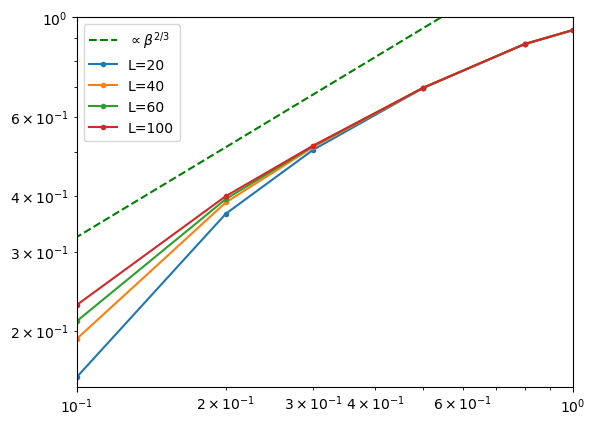

In [126]:
x = np.array(beta_list)
plt.xscale('log')
plt.yscale('log')
plt.plot(x, 1.5*np.power(x, 2/3), 'g--', label=r'$\propto \beta^{2/3}$')
# plt.plot(x, 10*np.power(x, 2), 'k--', label=r'$\propto \beta^{2}$')
plt.plot(beta_list, estimated_values_20, '.-', label="L=20")
plt.plot(beta_list, estimated_values_40, '.-', label="L=40")
plt.plot(beta_list, estimated_values_60, '.-', label="L=60")
plt.plot(beta_list, estimated_values_100, '.-', label="L=100")
plt.legend()
plt.xlim(0.1, 1.0)
plt.ylim(0.15, 1.0)

In [127]:
x = np.array([0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.5, 0.8, 1.0])
L_list = np.array([20, 40, 60, 100])
y = np.array([estimated_values_20, estimated_values_40, estimated_values_60, estimated_values_100])

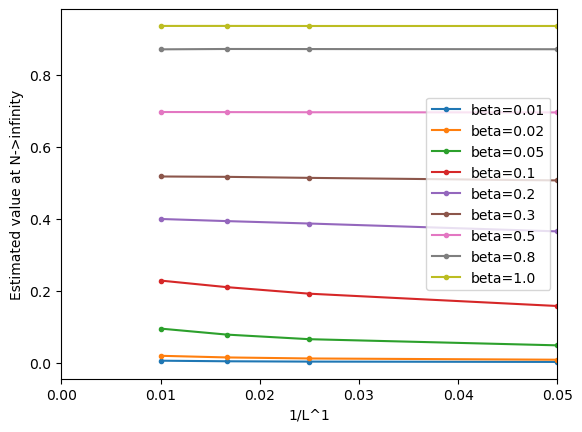

In [178]:
p = 1
for i in range(len(x)):
    plt.plot(1/L_list**p, y[:,i], '.-', label="beta="+str(x[i]))
plt.legend()
plt.xlabel('1/L^'+str(p))
plt.ylabel('Estimated value at N->infinity')
plt.xlim(0, max(1/L_list**p))
plt.xscale('linear')
plt.yscale('linear')
# plt.ylim(0.15, 1.0)

In [208]:
A = np.array([estimated_values_20, estimated_values_40, estimated_values_60, estimated_values_100])
beta_list = np.array([0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.5, 0.8, 1.0])
L_list = np.array([20, 40, 60, 100])
beta_list = beta_list[0:6]
A = A[:, 0:6]


In [209]:
A

array([[0.00215209, 0.00827585, 0.04818414, 0.15739608, 0.36456968,
        0.50611856],
       [0.00303895, 0.01172857, 0.06524118, 0.19158702, 0.38640363,
        0.51314944],
       [0.00395063, 0.01461796, 0.07802227, 0.20979584, 0.39312927,
        0.51600021],
       [0.00555913, 0.01916429, 0.09464737, 0.228     , 0.399     ,
        0.517     ]])

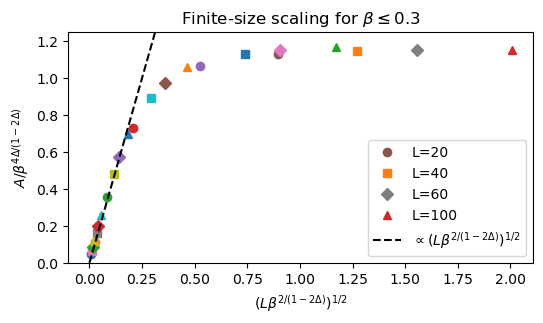

In [229]:
plt.figure(figsize=(6,3))
Delta = 1/8
x_list = []
y_list = []
mark_list = ['o', 's', 'D', '^', 'v', 'P']
for i in range(len(L_list)):
    for j in range(len(beta_list)):
        x = L_list[i] * np.power(beta_list[j], (2/(1-2*Delta)))
        y = A[i,j]/np.power(beta_list[j], 4*Delta/(1-2*Delta))
        x_list.append(x)
        y_list.append(y)
        label = None
        if j == len(beta_list)-1:
            label = "L="+str(L_list[i])
        plt.plot(x**(1/2), y, mark_list[i], label=label)
plt.plot([0,0.5], 4*np.array([0, 0.5]), 'k--', label=r'$\propto (L\beta^{2/(1-2\Delta)})^{1/2}$')
plt.xlabel(r'$(L\beta^{2/(1-2\Delta)})^{1/2}$')
plt.ylabel(r'$A/\beta^{4\Delta/(1-2\Delta)}$')
plt.legend()
plt.title(r'Finite-size scaling for $\beta \leq 0.3$')
plt.ylim(0, 1.25)
plt.savefig('finite_size_scaling_onepoint.pdf')

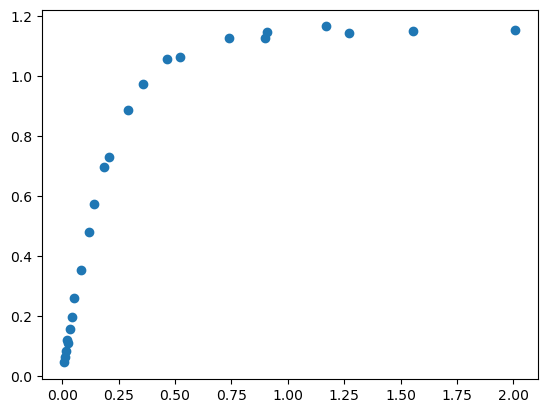

In [202]:
plt.plot(np.power(x_list, 1/2), y_list, 'o')

## Absolute moment of one-point function

L =  20
Estimated value at N->infinity for beta=0.01: 0.03719750758782778
Estimated value at N->infinity for beta=0.02: 0.07307655511337204
Estimated value at N->infinity for beta=0.05: 0.1765184309629541
Estimated value at N->infinity for beta=0.1: 0.3215085596384442
Estimated value at N->infinity for beta=0.2: 0.505476771081711
Estimated value at N->infinity for beta=0.3: 0.6135355363151453
Estimated values: [np.float64(0.03719750758782778), np.float64(0.07307655511337204), np.float64(0.1765184309629541), np.float64(0.3215085596384442), np.float64(0.505476771081711), np.float64(0.6135355363151453)]
L =  40


/tmp/ipykernel_280271/2891121150.py:82: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Estimated value at N->infinity for beta=0.01: 0.04429751230199592
Estimated value at N->infinity for beta=0.02: 0.08686755425422721
Estimated value at N->infinity for beta=0.05: 0.2050340949320091
Estimated value at N->infinity for beta=0.1: 0.35538215003636014
Estimated value at N->infinity for beta=0.2: 0.5231518510369588
Estimated value at N->infinity for beta=0.3: 0.6186375484792138
Estimated values: [np.float64(0.04429751230199592), np.float64(0.08686755425422721), np.float64(0.2050340949320091), np.float64(0.35538215003636014), np.float64(0.5231518510369588), np.float64(0.6186375484792138)]
L =  60


/tmp/ipykernel_280271/2891121150.py:82: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Estimated value at N->infinity for beta=0.01: 0.05054023234294257
Estimated value at N->infinity for beta=0.02: 0.09691138925392893
Estimated value at N->infinity for beta=0.05: 0.22410988690858855
Estimated value at N->infinity for beta=0.1: 0.3732444978502297
Estimated value at N->infinity for beta=0.2: 0.5294619589536264
Estimated value at N->infinity for beta=0.3: 0.6208132550964378
Estimated values: [np.float64(0.05054023234294257), np.float64(0.09691138925392893), np.float64(0.22410988690858855), np.float64(0.3732444978502297), np.float64(0.5294619589536264), np.float64(0.6208132550964378)]
L =  100


/tmp/ipykernel_280271/2891121150.py:82: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Estimated value at N->infinity for beta=0.01: 0.059922608471870996
Estimated value at N->infinity for beta=0.02: 0.11084190555642785
Estimated value at N->infinity for beta=0.05: 0.24738402721901243
Estimated value at N->infinity for beta=0.1: 0.3921542362335104
Estimated value at N->infinity for beta=0.2: 0.535081981895809
Estimated value at N->infinity for beta=0.3: 0.6218875070878936
Estimated values: [np.float64(0.059922608471870996), np.float64(0.11084190555642785), np.float64(0.24738402721901243), np.float64(0.3921542362335104), np.float64(0.535081981895809), np.float64(0.6218875070878936)]


/tmp/ipykernel_280271/2891121150.py:82: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


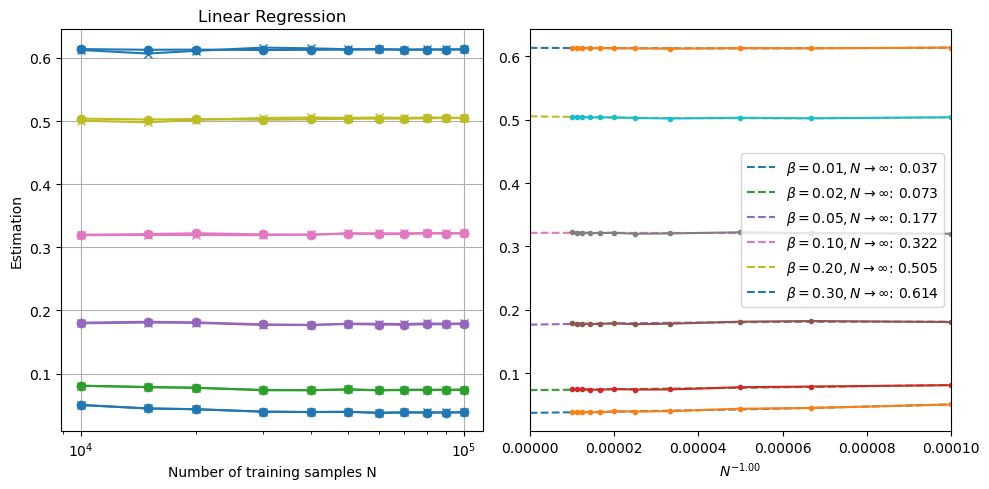

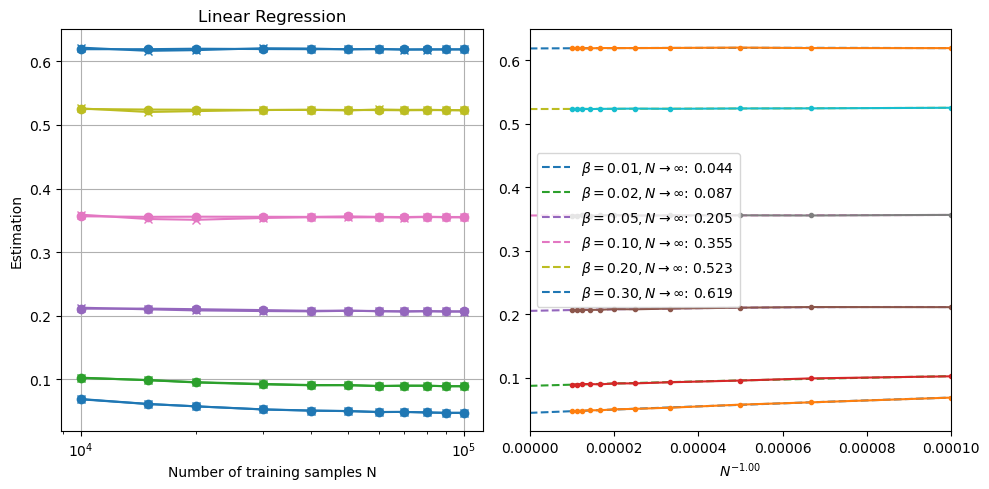

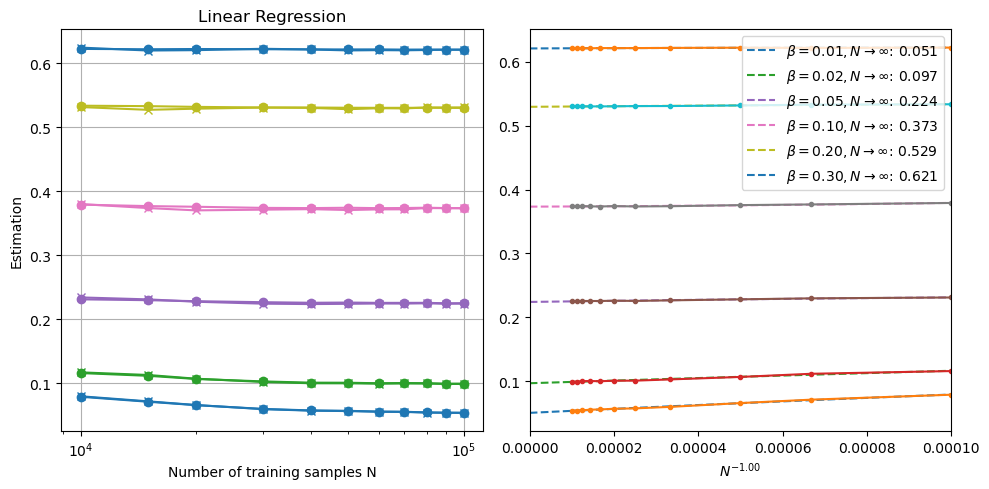

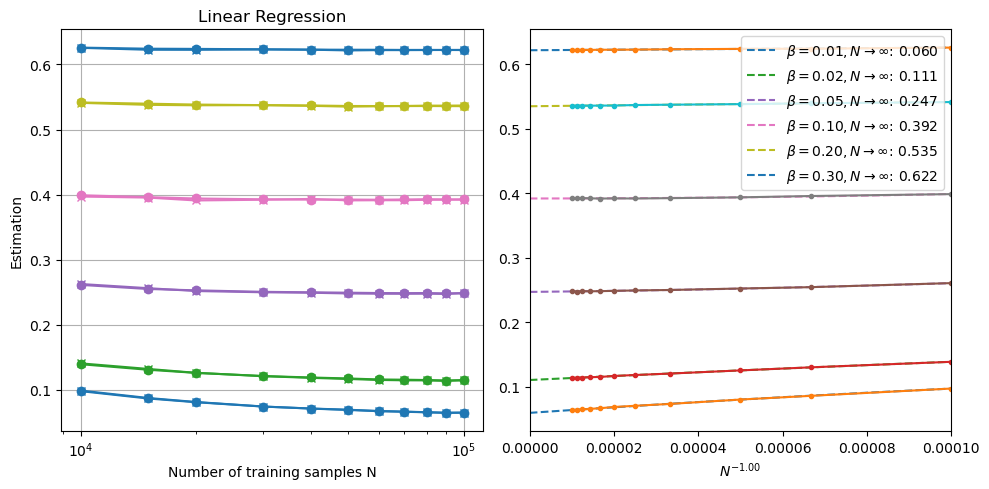

In [5]:
seed = 0
N_list = [10000, 15000, 20000,30000, 40000, 50000, 60000, 70000, 80000, 90000,100000]
beta_list = [0.01, 0.02, 0.05, 0.1, 0.2, 0.3]
q = 1
L_list = [20, 40, 60, 100]
A_q = []
for L in L_list:
    print("L = ", L)
    fig, axes = plt.subplots(1,2,figsize=(10,5))
    Estimated_value_list = []
    for beta in beta_list:
        try:
            sys_data = np.load(f"../data/Fast_CritIsing_L{L}_beta{beta}_Zoutcomes_sys_1e6.npy")
            anc_data = np.load(f"../data/Fast_CritIsing_L{L}_beta{beta}_Zoutcomes_anc_1e6.npy")
        except:
            sys_data = np.load(f"../data/Fast_CritIsing_L{L}_beta{beta}_Zoutcomes_sys.npy")
            anc_data = np.load(f"../data/Fast_CritIsing_L{L}_beta{beta}_Zoutcomes_anc.npy")
        sys_data = sys_data[:100000, :]
        anc_data = anc_data[:100000, :]
        sys_data = augment_data_Z2(sys_data, shuffle=True, seed=seed)
        anc_data = augment_data_Z2(anc_data, shuffle=True, seed=seed)
        np.random.seed(seed)
        indices = np.random.permutation(len(sys_data))

        A_list_train = []
        A_list_test = []
        for N in N_list:
            Abs_moment_train_list = []
            Abs_moment_test_list = []
            for i in range(L):
                X_train = anc_data[indices[:N]]
                y_train = sys_data[indices[:N], i]
                
                X_test = anc_data[indices[N:2*N]]
                y_test = sys_data[indices[N:2*N], i]
                
                my_model = LinearRegression(fit_intercept=False)
                my_model.fit(X_train, y_train)
                
                Abs_moment_train = np.mean(np.abs(my_model.predict(X_train))) ** q
                
                Abs_moment_train_list.append(Abs_moment_train)
                Abs_moment_test = np.mean(np.abs(my_model.predict(X_test))) ** q
                Abs_moment_test_list.append(Abs_moment_test)
            A_list_train.append(np.mean(Abs_moment_train_list))
            A_list_test.append(np.mean(Abs_moment_test_list))
        ax = axes[0]
        ax.plot(N_list, A_list_train, marker='o', label=f'L={L}')
        ax.plot(N_list, A_list_test, marker='x', label=f'L={L} (test)')
        ax.get_lines()[-1].set_color(ax.get_lines()[-2].get_color())


        ax = axes[1]
        y = np.array(A_list_train)
        x = np.array(N_list)
        powerlaw_exponent = 1.0
        x_ = 1/np.power(x,powerlaw_exponent)
        coefficients = np.polyfit(x_, y, 2)
        poly = np.poly1d(coefficients)
        x_fit = np.linspace(0, max(x_), 100)
        y_fit = poly(x_fit)
        ax.plot(x_fit, y_fit, '--', label=r'$\beta = %.2f, N\to\infty$: %.3f' % (beta, poly(0)))
        ax.plot(x_, y, '.-')
        Estimated_value_list.append(poly(0))
        print(f"Estimated value at N->infinity for beta={beta}: {poly(0)}")
    print(f"Estimated values: {Estimated_value_list}")
    A_q.append(Estimated_value_list)
    ax = axes[0]
    ax.set_xscale('log')
    # ax.set_yscale('log')
    ax.set_xlabel('Number of training samples N')
    ax.set_ylabel('Estimation')
    ax.set_title('Linear Regression')
    ax.grid(True)

    ax = axes[1]
    ax.set_xlim(0, max(x_))
    ax.legend()

    ax.set_xlabel(r'$N^{%.2f}$' % (-powerlaw_exponent))
    fig.tight_layout()
    fig.show()

In [6]:
A = np.array(A_q)

In [27]:
print(A_q)

[[np.float64(0.03719750758782778), np.float64(0.07307655511337204), np.float64(0.1765184309629541), np.float64(0.3215085596384442), np.float64(0.505476771081711), np.float64(0.6135355363151453)], [np.float64(0.04429751230199592), np.float64(0.08686755425422721), np.float64(0.2050340949320091), np.float64(0.35538215003636014), np.float64(0.5231518510369588), np.float64(0.6186375484792138)], [np.float64(0.05054023234294257), np.float64(0.09691138925392893), np.float64(0.22410988690858855), np.float64(0.3732444978502297), np.float64(0.5294619589536264), np.float64(0.6208132550964378)], [np.float64(0.059922608471870996), np.float64(0.11084190555642785), np.float64(0.24738402721901243), np.float64(0.3921542362335104), np.float64(0.535081981895809), np.float64(0.6218875070878936)]]


In [26]:
print(A)

[[0.03719751 0.07307656 0.17651843 0.32150856 0.50547677 0.61353554]
 [0.04429751 0.08686755 0.20503409 0.35538215 0.52315185 0.61863755]
 [0.05054023 0.09691139 0.22410989 0.3732445  0.52946196 0.62081326]
 [0.05992261 0.11084191 0.24738403 0.39215424 0.53508198 0.62188751]]


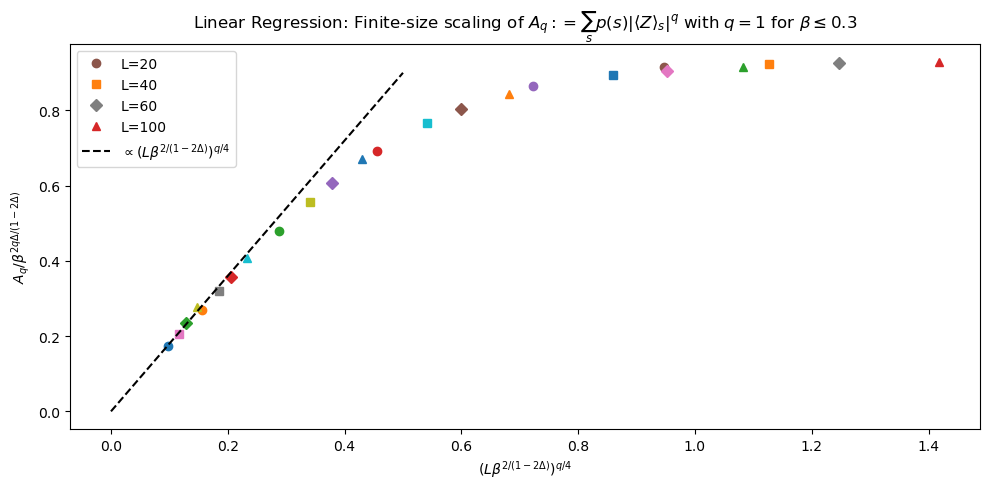

In [25]:
plt.figure(figsize=(10,5))
model_name = "Linear Regression"
q = 1
Delta = 1/8
x_list = []
y_list = []
mark_list = ['o', 's', 'D', '^', 'v', 'P']
for i in range(len(L_list)):
    for j in range(len(beta_list)):
        x = L_list[i] * np.power(beta_list[j], (2/(1-2*Delta)))
        y = A[i,j]/np.power(beta_list[j], 2*q*Delta/(1-2*Delta))
        x_list.append(x)
        y_list.append(y)
        label = None
        if j == len(beta_list)-1:
            label = "L="+str(L_list[i])
        plt.plot(x**(q/4), y, mark_list[i], label=label)
plt.plot([0,0.5], 1.8*np.array([0, 0.5]), 'k--', label=r'$\propto (L\beta^{2/(1-2\Delta)})^{q/4}$')
plt.xlabel(r'$(L\beta^{2/(1-2\Delta)})^{q/4}$')
plt.ylabel(r'$A_q/\beta^{2q\Delta/(1-2\Delta)}$')
plt.legend()
plt.title(model_name + ": " + r'Finite-size scaling of $A_q := \sum_s p(s) |\langle Z \rangle_s|^q$ with $q=%d$ for $\beta \leq 0.3$' % q)
plt.tight_layout()
# plt.ylim(0, 1.25)


### Physical ansatz with majority vote within some window

In [29]:
distance_1d

NameError: name 'distance_1d' is not defined

In [32]:
def distance_1d(x, L, bc="periodic"):
    # return a list, representing the distance of each point in [0, 1, ..., L-1] to x
    if x < 0 or x >= L:
        raise ValueError("x must be between 0 and L-1")
    if bc == "periodic":
        return np.minimum(np.abs(np.arange(L) - x), L - np.abs(np.arange(L) - x))
    elif bc == "open":
        return np.abs(np.arange(L) - x)
    else:
        raise ValueError("Invalid boundary condition")

In [43]:
distance_1d(9, 10)**2

array([ 1,  4,  9, 16, 25, 16,  9,  4,  1,  0])

In [53]:
class MajorityVoteClassifier():
    def __init__(self, L, center=0, bc="periodic", cutoff="soft"):
        self.L = L
        self.center = center
        self.bc = bc
        self.cutoff = cutoff
        self.l = None # length scale of the majority vote window, to be obtained by training
        self.weights = None
        self.training_accuracy = None
    def fit(self, X, y):
        if self.bc == "periodic" or self.bc == "open":
            distances = distance_1d(self.center, self.L, bc=self.bc)
            best_acc = 0
            best_weights = None
            if self.cutoff == "hard":
                for l in range(self.L):
                    weights = (distances <= l).astype(float)
                    weights /= np.sum(weights)
                    y_pred = np.sign(X @ weights)
                    acc = np.mean(y_pred == y)
                    if acc > best_acc + 1e-6:
                        best_acc = acc
                        self.l = l
                        best_weights = weights
            elif self.cutoff == "soft":
                for l in range(3*self.L):
                    l_ = l + 0.01
                    weights = np.exp(-distances**2/l_**2)
                    weights /= np.sum(weights)
                    y_pred = np.sign(X @ weights)
                    acc = np.mean(y_pred == y)
                    if acc > best_acc + 1e-6:
                        best_acc = acc
                        self.l = l_
                        best_weights = weights
            else:
                raise ValueError("Invalid cutoff type. Use 'hard' or 'soft'.")
            self.weights = best_weights
            self.training_accuracy = best_acc
            
        else:
            raise ValueError("Invalid boundary condition. Use 'periodic' or 'open'.")

    def predict(self, X):
        return np.sign(X @ self.weights)


In [ ]:
seed = 0
N_list = [10000, 15000, 20000,30000, 40000, 50000, 60000, 70000, 80000, 90000,100000]
N_list = [10000, 15000, 20000,30000, 40000, 50000, 60000, 70000, 80000, 90000,100000]
beta_list = [0.01, 0.02, 0.05, 0.1, 0.2, 0.3]
q = 1
L_list = [20, 40, 60, 100]
A_q = []
for L in L_list:
    print("L = ", L)
    fig, axes = plt.subplots(1,2,figsize=(10,5))
    Estimated_value_list = []
    for beta in beta_list:
        try:
            sys_data = np.load(f"../data/Fast_CritIsing_L{L}_beta{beta}_Zoutcomes_sys_1e6.npy")
            anc_data = np.load(f"../data/Fast_CritIsing_L{L}_beta{beta}_Zoutcomes_anc_1e6.npy")
        except:
            sys_data = np.load(f"../data/Fast_CritIsing_L{L}_beta{beta}_Zoutcomes_sys.npy")
            anc_data = np.load(f"../data/Fast_CritIsing_L{L}_beta{beta}_Zoutcomes_anc.npy")
        sys_data = sys_data[:100000, :]
        anc_data = anc_data[:100000, :]
        sys_data = augment_data_Z2(sys_data, shuffle=True, seed=seed)
        anc_data = augment_data_Z2(anc_data, shuffle=True, seed=seed)
        np.random.seed(seed)
        indices = np.random.permutation(len(sys_data))

        A_list_train = []
        A_list_test = []
        for N in N_list:
            Abs_moment_train_list = []
            Abs_moment_test_list = []
            for i in range(L):
                X_train = anc_data[indices[:N]]
                y_train = sys_data[indices[:N], i]
                
                X_test = anc_data[indices[N:2*N]]
                y_test = sys_data[indices[N:2*N], i]
                
                
                
                my_model = MajorityVoteClassifier(L=L, center=i, bc="periodic", cutoff="hard")
                my_model.fit(X_train, y_train)
                
                Abs_moment_train = np.mean(my_model.predict(X_train) * y_train)
                
                Abs_moment_train_list.append(Abs_moment_train)
                Abs_moment_test = np.mean(my_model.predict(X_test) * y_test)
                Abs_moment_test_list.append(Abs_moment_test)
                
                
                
                
            A_list_train.append(np.mean(Abs_moment_train_list))
            A_list_test.append(np.mean(Abs_moment_test_list))
        ax = axes[0]
        ax.plot(N_list, A_list_train, marker='o', label=f'L={L}')
        ax.plot(N_list, A_list_test, marker='x', label=f'L={L} (test)')
        ax.get_lines()[-1].set_color(ax.get_lines()[-2].get_color())


        ax = axes[1]
        y = np.array(A_list_train)
        x = np.array(N_list)
        powerlaw_exponent = 1.0
        x_ = 1/np.power(x,powerlaw_exponent)
        coefficients = np.polyfit(x_, y, 2)
        poly = np.poly1d(coefficients)
        x_fit = np.linspace(0, max(x_), 100)
        y_fit = poly(x_fit)
        ax.plot(x_fit, y_fit, '--', label=r'$\beta = %.2f, N\to\infty$: %.3f' % (beta, poly(0)))
        ax.plot(x_, y, '.-')
        Estimated_value_list.append(poly(0))
        print(f"Estimated value at N->infinity for beta={beta}: {poly(0)}")
    print(f"Estimated values: {Estimated_value_list}")
    A_q.append(Estimated_value_list)
    ax = axes[0]
    ax.set_xscale('log')
    # ax.set_yscale('log')
    ax.set_xlabel('Number of training samples N')
    ax.set_ylabel('Estimation')
    ax.set_title('Majority Vote Classifier')
    ax.grid(True)

    ax = axes[1]
    ax.set_xlim(0, max(x_))
    ax.legend()

    ax.set_xlabel(r'$N^{%.2f}$' % (-powerlaw_exponent))
    fig.tight_layout()
    fig.show()

L =  20
Estimated value at N->infinity for beta=0.01: 0.03298178970244206
Estimated value at N->infinity for beta=0.02: 0.06740941567282882
Estimated value at N->infinity for beta=0.05: 0.17013057572023424
Estimated value at N->infinity for beta=0.1: 0.32504037156633064
Estimated value at N->infinity for beta=0.2: 0.5230306575047959


L =  20
Estimated value at N->infinity for beta=0.01: 0.033578718181072845
Estimated value at N->infinity for beta=0.02: 0.06909005138851286
Estimated value at N->infinity for beta=0.05: 0.173831592481069
Estimated value at N->infinity for beta=0.1: 0.33271428908766615
Estimated value at N->infinity for beta=0.2: 0.5394135879634476
Estimated value at N->infinity for beta=0.3: 0.6421856291139617
Estimated values: [np.float64(0.033578718181072845), np.float64(0.06909005138851286), np.float64(0.173831592481069), np.float64(0.33271428908766615), np.float64(0.5394135879634476), np.float64(0.6421856291139617)]
L =  40


/tmp/ipykernel_280271/4000655411.py:89: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Estimated value at N->infinity for beta=0.01: 0.04038796946955404
Estimated value at N->infinity for beta=0.02: 0.08392139796002925
Estimated value at N->infinity for beta=0.05: 0.2049816438921872
Estimated value at N->infinity for beta=0.1: 0.3739147263966571
Estimated value at N->infinity for beta=0.2: 0.5559506640140636
Estimated value at N->infinity for beta=0.3: 0.6387777231373586
Estimated values: [np.float64(0.04038796946955404), np.float64(0.08392139796002925), np.float64(0.2049816438921872), np.float64(0.3739147263966571), np.float64(0.5559506640140636), np.float64(0.6387777231373586)]
L =  60
Estimated value at N->infinity for beta=0.01: 0.04720477401162317
Estimated value at N->infinity for beta=0.02: 0.09477501959721422
Estimated value at N->infinity for beta=0.05: 0.22722284077228141
Estimated value at N->infinity for beta=0.1: 0.3969831505204481
Estimated value at N->infinity for beta=0.2: 0.5563535071262069
Estimated value at N->infinity for beta=0.3: 0.6384946077557139


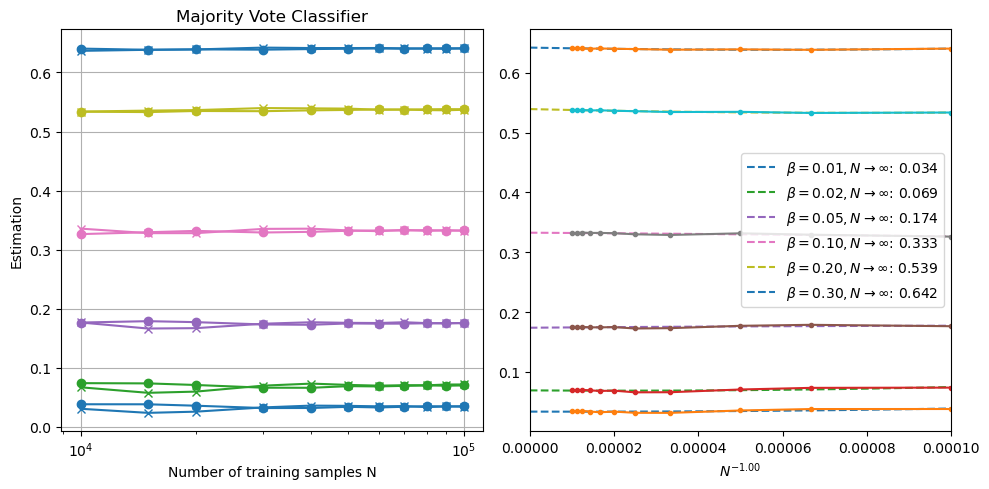

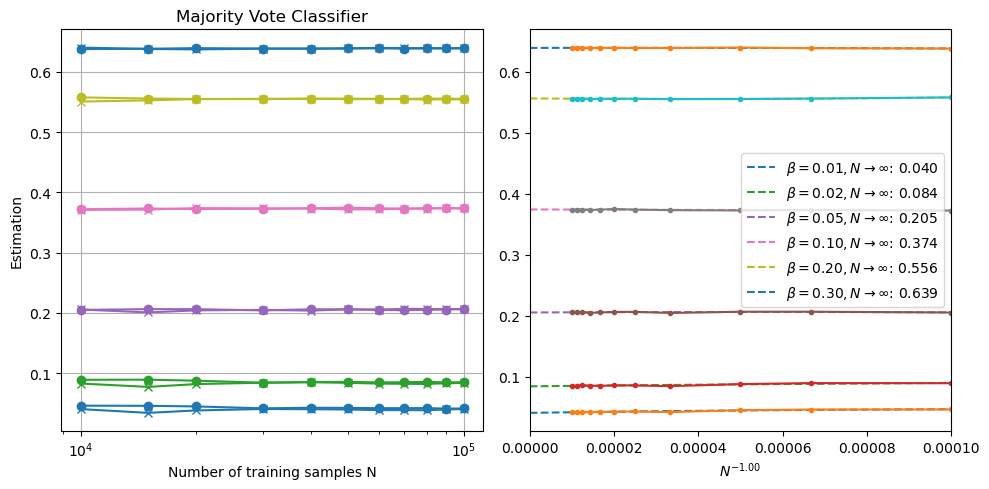

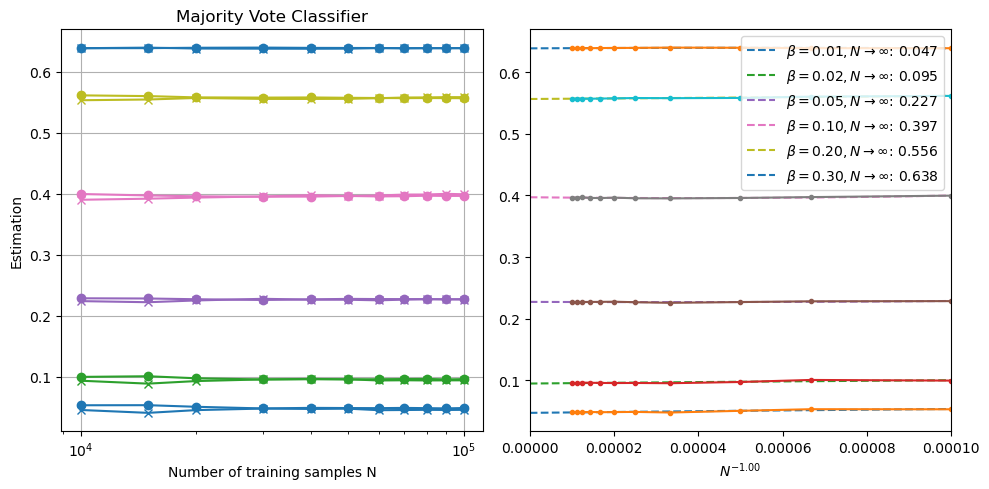

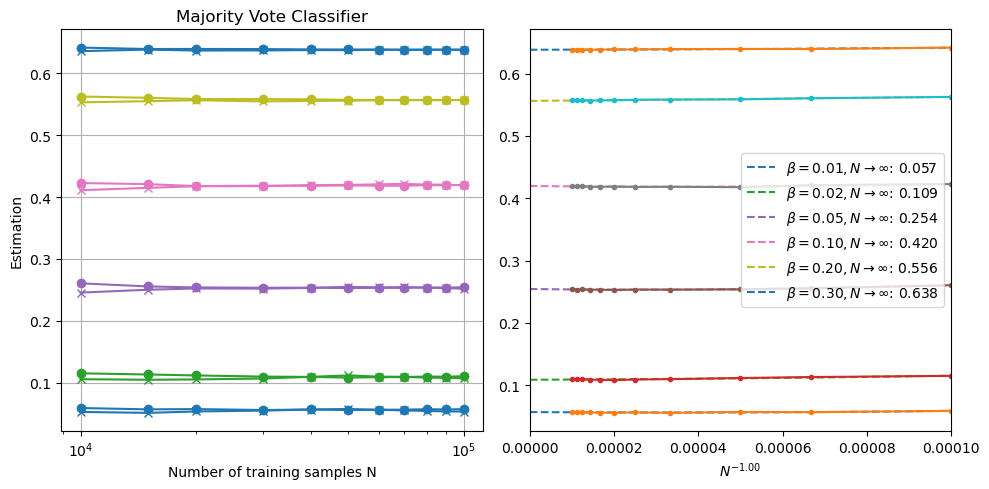

In [55]:
seed = 0
N_list = [10000, 15000, 20000,30000, 40000, 50000, 60000, 70000, 80000, 90000,100000]
N_list = [10000, 15000, 20000,30000, 40000, 50000, 60000, 70000, 80000, 90000,100000]
beta_list = [0.01, 0.02, 0.05, 0.1, 0.2, 0.3]
q = 1
L_list = [20, 40, 60, 100]
A_q = []
for L in L_list:
    print("L = ", L)
    fig, axes = plt.subplots(1,2,figsize=(10,5))
    Estimated_value_list = []
    for beta in beta_list:
        try:
            sys_data = np.load(f"../data/Fast_CritIsing_L{L}_beta{beta}_Zoutcomes_sys_1e6.npy")
            anc_data = np.load(f"../data/Fast_CritIsing_L{L}_beta{beta}_Zoutcomes_anc_1e6.npy")
        except:
            sys_data = np.load(f"../data/Fast_CritIsing_L{L}_beta{beta}_Zoutcomes_sys.npy")
            anc_data = np.load(f"../data/Fast_CritIsing_L{L}_beta{beta}_Zoutcomes_anc.npy")
        sys_data = sys_data[:100000, :]
        anc_data = anc_data[:100000, :]
        sys_data = augment_data_Z2(sys_data, shuffle=True, seed=seed)
        anc_data = augment_data_Z2(anc_data, shuffle=True, seed=seed)
        np.random.seed(seed)
        indices = np.random.permutation(len(sys_data))

        A_list_train = []
        A_list_test = []
        for N in N_list:
            Abs_moment_train_list = []
            Abs_moment_test_list = []
            for i in range(L):
                X_train = anc_data[indices[:N]]
                y_train = sys_data[indices[:N], i]
                
                X_test = anc_data[indices[N:2*N]]
                y_test = sys_data[indices[N:2*N], i]
                
                
                
                my_model = MajorityVoteClassifier(L=L, center=i, bc="periodic", cutoff="soft")
                my_model.fit(X_train, y_train)
                
                Abs_moment_train = np.mean(my_model.predict(X_train) * y_train)
                
                Abs_moment_train_list.append(Abs_moment_train)
                Abs_moment_test = np.mean(my_model.predict(X_test) * y_test)
                Abs_moment_test_list.append(Abs_moment_test)
                
                
                
                
            A_list_train.append(np.mean(Abs_moment_train_list))
            A_list_test.append(np.mean(Abs_moment_test_list))
        ax = axes[0]
        ax.plot(N_list, A_list_train, marker='o', label=f'L={L}')
        ax.plot(N_list, A_list_test, marker='x', label=f'L={L} (test)')
        ax.get_lines()[-1].set_color(ax.get_lines()[-2].get_color())


        ax = axes[1]
        y = np.array(A_list_train)
        x = np.array(N_list)
        powerlaw_exponent = 1.0
        x_ = 1/np.power(x,powerlaw_exponent)
        coefficients = np.polyfit(x_, y, 2)
        poly = np.poly1d(coefficients)
        x_fit = np.linspace(0, max(x_), 100)
        y_fit = poly(x_fit)
        ax.plot(x_fit, y_fit, '--', label=r'$\beta = %.2f, N\to\infty$: %.3f' % (beta, poly(0)))
        ax.plot(x_, y, '.-')
        Estimated_value_list.append(poly(0))
        print(f"Estimated value at N->infinity for beta={beta}: {poly(0)}")
    print(f"Estimated values: {Estimated_value_list}")
    A_q.append(Estimated_value_list)
    ax = axes[0]
    ax.set_xscale('log')
    # ax.set_yscale('log')
    ax.set_xlabel('Number of training samples N')
    ax.set_ylabel('Estimation')
    ax.set_title('Majority Vote Classifier')
    ax.grid(True)

    ax = axes[1]
    ax.set_xlim(0, max(x_))
    ax.legend()

    ax.set_xlabel(r'$N^{%.2f}$' % (-powerlaw_exponent))
    fig.tight_layout()
    fig.show()

In [56]:
print(A_q)
A = np.array(A_q)
print(A)

[[np.float64(0.033578718181072845), np.float64(0.06909005138851286), np.float64(0.173831592481069), np.float64(0.33271428908766615), np.float64(0.5394135879634476), np.float64(0.6421856291139617)], [np.float64(0.04038796946955404), np.float64(0.08392139796002925), np.float64(0.2049816438921872), np.float64(0.3739147263966571), np.float64(0.5559506640140636), np.float64(0.6387777231373586)], [np.float64(0.04720477401162317), np.float64(0.09477501959721422), np.float64(0.22722284077228141), np.float64(0.3969831505204481), np.float64(0.5563535071262069), np.float64(0.6384946077557139)], [np.float64(0.05680263260830402), np.float64(0.10867097742207926), np.float64(0.2542729518915452), np.float64(0.41964532116438563), np.float64(0.5562728553424697), np.float64(0.6383475570855702)]]
[[0.03357872 0.06909005 0.17383159 0.33271429 0.53941359 0.64218563]
 [0.04038797 0.0839214  0.20498164 0.37391473 0.55595066 0.63877772]
 [0.04720477 0.09477502 0.22722284 0.39698315 0.55635351 0.63849461]
 [0.0

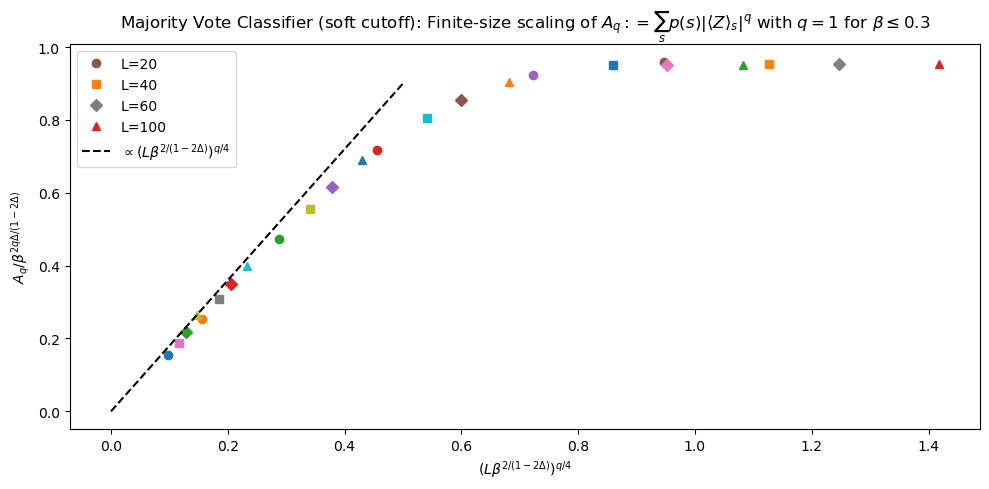

In [57]:
plt.figure(figsize=(10,5))
model_name = "Majority Vote Classifier (soft cutoff)"
q = 1
Delta = 1/8
x_list = []
y_list = []
mark_list = ['o', 's', 'D', '^', 'v', 'P']
for i in range(len(L_list)):
    for j in range(len(beta_list)):
        x = L_list[i] * np.power(beta_list[j], (2/(1-2*Delta)))
        y = A[i,j]/np.power(beta_list[j], 2*q*Delta/(1-2*Delta))
        x_list.append(x)
        y_list.append(y)
        label = None
        if j == len(beta_list)-1:
            label = "L="+str(L_list[i])
        plt.plot(x**(q/4), y, mark_list[i], label=label)
plt.plot([0,0.5], 1.8*np.array([0, 0.5]), 'k--', label=r'$\propto (L\beta^{2/(1-2\Delta)})^{q/4}$')
plt.xlabel(r'$(L\beta^{2/(1-2\Delta)})^{q/4}$')
plt.ylabel(r'$A_q/\beta^{2q\Delta/(1-2\Delta)}$')
plt.legend()
plt.title(model_name + ": " + r'Finite-size scaling of $A_q := \sum_s p(s) |\langle Z \rangle_s|^q$ with $q=%d$ for $\beta \leq 0.3$' % q)
plt.tight_layout()
# plt.ylim(0, 1.25)


exponent -0.421870254033122 intercept -4.290213330902699


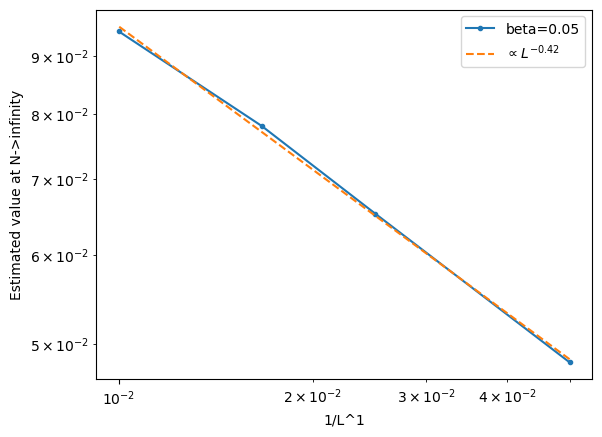

In [175]:
p = 1
i = 2
plt.plot(1/L_list**p, y[:,i], '.-', label="beta="+str(x[i]))
plt.legend()
plt.xlabel('1/L^'+str(p))
plt.ylabel('Estimated value at N->infinity')
# plt.xlim(0, max(1/L_list**p))
plt.xscale('log')
plt.yscale('log')

poly = np.poly1d(np.polyfit(np.log(1/L_list**p), np.log(y[:,i]), 1))
y_fit = np.exp(poly(np.log(1/L_list**p)))
plt.plot(1/L_list**p, y_fit, '--', label=r'$\propto L^{%.2f}$' % poly.coefficients[0])
print("exponent", poly.coefficients[0], "intercept", poly.coefficients[1])

plt.legend()
# plt.ylim(0.15, 1.0)

In [165]:
poly

poly1d([-0.52244196, -6.36441656])

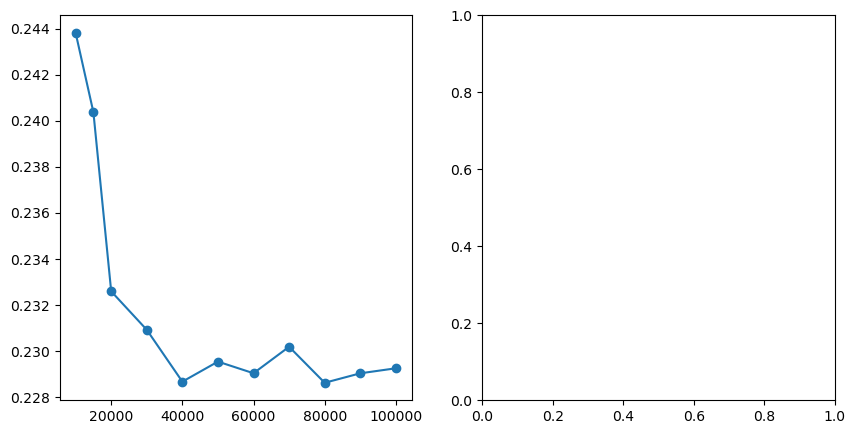

In [ ]:
fig, axes = plt.subplots(1,2,figsize=(10,5))
beta_list = [0.1] # 0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.5, 0.8, 1.0
N_list = [10000, 15000, 20000,30000, 40000, 50000, 60000, 70000, 80000, 90000,100000]
for beta in beta_list:
    A_list = []
    for N in N_list:
        for i in range(L):
        X_train = anc_data[:N, :]
        y_train = sys_data[:N, 0]

        X_train = augment_data_Z2(X_train, shuffle=True, seed=seed)
        y_train = augment_data_Z2(y_train.reshape(-1, 1), shuffle=True, seed=seed).flatten()
        
        model = LinearRegression(fit_intercept=False)
        model.fit(X_train, y_train)
        MSE = mean_squared_error(y_train, model.predict(X_train))
        A_list.append(1 - MSE)
    
    ax = axes[0]
    ax.plot(N_list, A_list, marker='o', label=f'L={L}')
    

# XGBoost

In [5]:
sys_data = np.load("data/CritIsing_L20_beta0.3_Zoutcomes_sys.npy")
anc_data = np.load("data/CritIsing_L20_beta0.3_Zoutcomes_anc.npy")

In [28]:
N = 100000
seed = 0
np.random.seed(seed)
indices = np.random.permutation(len(sys_data))
X_train = anc_data[indices[:N]]
y_train = sys_data[indices[:N], 0]

In [32]:
my_model = XGBRegressor(n_estimators=100, seed=42)
my_model.fit(X_train, y_train)
MSE_train = mean_squared_error(y_train, my_model.predict(X_train))

In [33]:
1 - MSE_train

0.5570089519023895

8 0.49740755558013916
10 0.5088864862918854
12 0.5193032920360565
14 0.5269168615341187
16 0.5318341851234436
18 0.5350159704685211
20 0.5371703207492828
40 0.5485050678253174


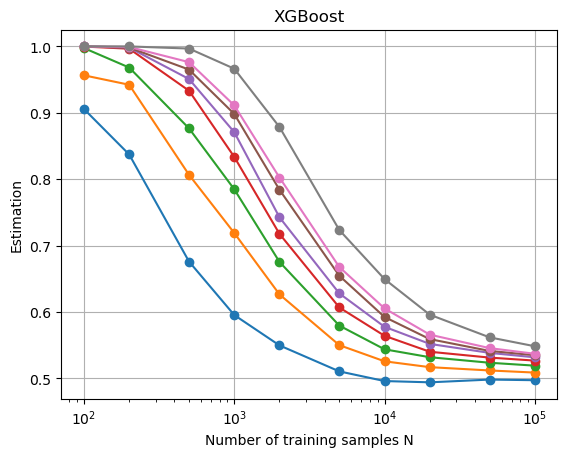

In [54]:
n_estimators = 20
xgb_seed = 42
N_list = [100, 200, 500, 1000, 2000, 5000, 10000, 20000, 50000, 100000]
for L in [8, 10, 12, 14, 16, 18, 20, 40]:
    sys_data = np.load(f"data/CritIsing_L{L}_beta0.3_Zoutcomes_sys.npy")
    anc_data = np.load(f"data/CritIsing_L{L}_beta0.3_Zoutcomes_anc.npy")

    A_list = []
    for N in N_list:
        X_train = anc_data[indices[:N]]
        y_train = sys_data[indices[:N], 0]
        
        my_model = XGBRegressor(n_estimators=n_estimators, seed=xgb_seed)
        my_model.fit(X_train, y_train)
        MSE_train = mean_squared_error(y_train, my_model.predict(X_train))
        A_list.append(1 - MSE_train)

    plt.plot(N_list, A_list, marker='o', label=f'L={L}')
    print(L, A_list[-1])
plt.xscale('log')
plt.xlabel('Number of training samples N')
plt.ylabel('Estimation')
plt.title('XGBoost')
plt.grid(True)

Extrapolated value at N->infinity: 0.8776537004979084


Text(0.5, 0, '$N^{-1.00}$')

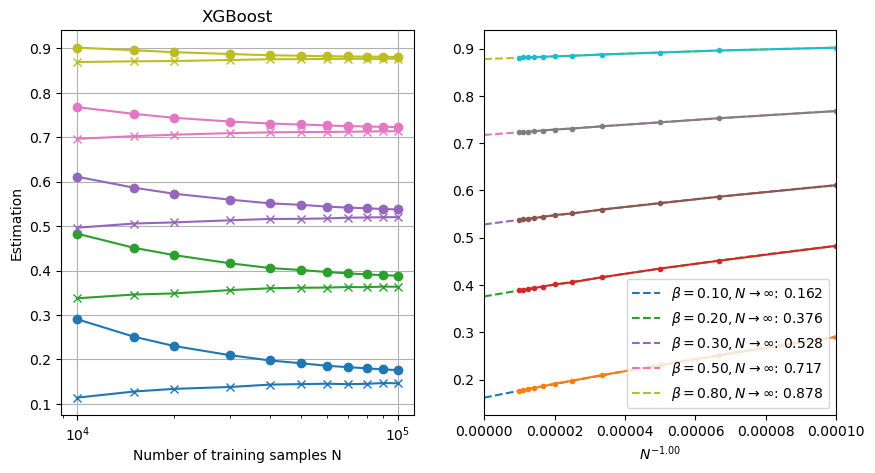

In [31]:

fig, axes = plt.subplots(1,2,figsize=(10,5))

n_estimators = 20
xgb_seed = 42
N_list = [10000, 15000, 20000,30000, 40000, 50000, 60000, 70000, 80000, 90000,100000]
L = 20
beta_list = [0.1, 0.2, 0.3, 0.5, 0.8]
Estimated_value_list = []
for beta in beta_list:
    seed = 2
    np.random.seed(seed)
    sys_data = np.load(f"temp/Fast_CritIsing_L{L}_beta{beta}_Zoutcomes_sys.npy")
    anc_data = np.load(f"temp/Fast_CritIsing_L{L}_beta{beta}_Zoutcomes_anc.npy")
    sys_data = augment_data_Z2(sys_data, shuffle=True, seed=seed)
    anc_data = augment_data_Z2(anc_data, shuffle=True, seed=seed)
    
    indices = np.random.permutation(len(sys_data))

    A_list_train = []
    A_list_test = []
    for N in N_list:
        MSE_train_list = []
        MSE_test_list = []
        for i in range(L):
            X_train = anc_data[indices[:N]]
            y_train = sys_data[indices[:N], i]
            
            X_test = anc_data[indices[N:2*N]]
            y_test = sys_data[indices[N:2*N], i]
            
            my_model = XGBRegressor(n_estimators=n_estimators, seed=xgb_seed, max_depth=6)
            my_model.fit(X_train, y_train)
            MSE_train = mean_squared_error(y_train, my_model.predict(X_train))
            MSE_train_list.append(MSE_train)
            MSE_test = mean_squared_error(y_test, my_model.predict(X_test))
            MSE_test_list.append(MSE_test)
        A_list_train.append(1-np.mean(MSE_train_list))
        A_list_test.append(1-np.mean(MSE_test_list))
    ax = axes[0]
    ax.plot(N_list, A_list_train, marker='o', label=f'L={L}')
    ax.plot(N_list, A_list_test, marker='x', label=f'L={L} (test)')
    ax.get_lines()[-1].set_color(ax.get_lines()[-2].get_color())


    ax = axes[1]
    y = np.array(A_list_train)
    x = np.array(N_list)
    powerlaw_exponent = 1.0
    x_ = 1/np.power(x,powerlaw_exponent)
    coefficients = np.polyfit(x_, y, 2)
    poly = np.poly1d(coefficients)
    x_fit = np.linspace(0, max(x_), 100)
    y_fit = poly(x_fit)
    ax.plot(x_fit, y_fit, '--', label=r'$\beta = %.2f, N\to\infty$: %.3f' % (beta, poly(0)))
    ax.plot(x_, y, '.-')
    Estimated_value_list.append(poly(0))

ax = axes[0]
ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel('Number of training samples N')
ax.set_ylabel('Estimation')
ax.set_title('XGBoost')
ax.grid(True)

ax = axes[1]
ax.set_xlim(0, max(x_))
ax.legend()

print("Extrapolated value at N->infinity:", poly(0))
ax.set_xlabel(r'$N^{%.2f}$' % (-powerlaw_exponent))

Extrapolated value at N->infinity: 0.8785431652315622


Text(0.5, 0, '$N^{-1.00}$')

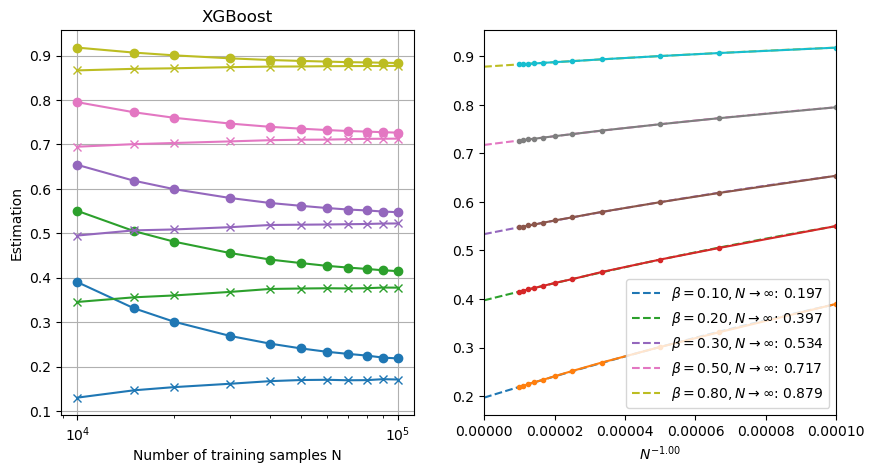

In [45]:

fig, axes = plt.subplots(1,2,figsize=(10,5))

n_estimators = 20
xgb_seed = 42
N_list = [10000, 15000, 20000,30000, 40000, 50000, 60000, 70000, 80000, 90000,100000]
L = 40
beta_list = [0.1, 0.2, 0.3, 0.5, 0.8]
Estimated_value_list = []
for beta in beta_list:
    seed = 2
    np.random.seed(seed)
    sys_data = np.load(f"temp/Fast_CritIsing_L{L}_beta{beta}_Zoutcomes_sys.npy")
    anc_data = np.load(f"temp/Fast_CritIsing_L{L}_beta{beta}_Zoutcomes_anc.npy")
    sys_data = augment_data_Z2(sys_data, shuffle=True, seed=seed)
    anc_data = augment_data_Z2(anc_data, shuffle=True, seed=seed)
    
    indices = np.random.permutation(len(sys_data))

    A_list_train = []
    A_list_test = []
    for N in N_list:
        MSE_train_list = []
        MSE_test_list = []
        for i in range(L):
            X_train = anc_data[indices[:N]]
            y_train = sys_data[indices[:N], i]
            
            X_test = anc_data[indices[N:2*N]]
            y_test = sys_data[indices[N:2*N], i]
            
            my_model = XGBRegressor(n_estimators=n_estimators, seed=xgb_seed, max_depth=6)
            my_model.fit(X_train, y_train)
            MSE_train = mean_squared_error(y_train, my_model.predict(X_train))
            MSE_train_list.append(MSE_train)
            MSE_test = mean_squared_error(y_test, my_model.predict(X_test))
            MSE_test_list.append(MSE_test)
        A_list_train.append(1-np.mean(MSE_train_list))
        A_list_test.append(1-np.mean(MSE_test_list))
    ax = axes[0]
    ax.plot(N_list, A_list_train, marker='o', label=f'L={L}')
    ax.plot(N_list, A_list_test, marker='x', label=f'L={L} (test)')
    ax.get_lines()[-1].set_color(ax.get_lines()[-2].get_color())


    ax = axes[1]
    y = np.array(A_list_train)
    x = np.array(N_list)
    powerlaw_exponent = 1.0
    x_ = 1/np.power(x,powerlaw_exponent)
    coefficients = np.polyfit(x_, y, 2)
    poly = np.poly1d(coefficients)
    x_fit = np.linspace(0, max(x_), 100)
    y_fit = poly(x_fit)
    ax.plot(x_fit, y_fit, '--', label=r'$\beta = %.2f, N\to\infty$: %.3f' % (beta, poly(0)))
    ax.plot(x_, y, '.-')
    Estimated_value_list.append(poly(0))

ax = axes[0]
ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel('Number of training samples N')
ax.set_ylabel('Estimation')
ax.set_title('XGBoost')
ax.grid(True)

ax = axes[1]
ax.set_xlim(0, max(x_))
ax.legend()

print("Extrapolated value at N->infinity:", poly(0))
ax.set_xlabel(r'$N^{%.2f}$' % (-powerlaw_exponent))

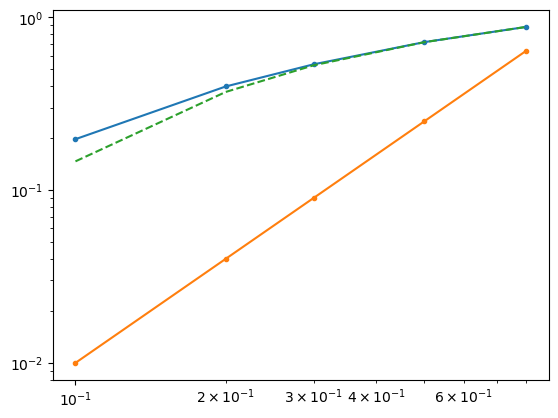

In [46]:
plt.plot(beta_list, Estimated_value_list, '.-', label="Estimated")
x = np.array(beta_list)
y = np.array(Estimated_value_list)
plt.xscale('log')
plt.yscale('log')
plt.plot(x, np.power(x, 2), '.-')

y_theory = []
for beta in beta_list:
    y_theory.append(np.load(f'temp/CritIsing_L16_beta{beta}_Zsecond_moment_theory.npy'))

y_theory = np.array(y_theory)
plt.xscale('log')
plt.yscale('log')
plt.plot(x, y_theory, '--', label="Theory")

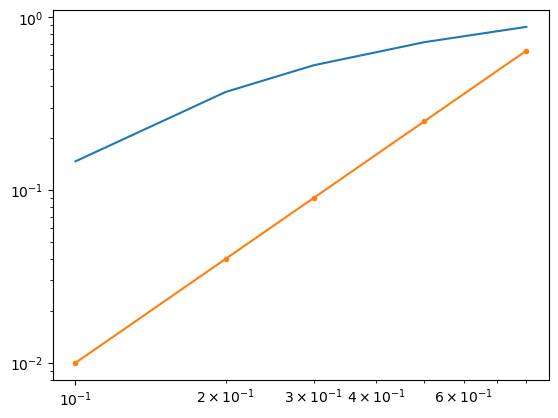

In [40]:

fig = plt.plot(figsize=(8, 5))
ax = plt.gca()
L = 16
# beta_list = [0.001, 0.002, 0.005, 0.01,0.02, 0.03, 0.05, 0.1, 0.2, 0.3, 0.5, 0.8, 1.0]
beta_list = [0.1, 0.2, 0.3, 0.5, 0.8]
results = []
y = []
for beta in beta_list:
    y.append(np.load(f'temp/CritIsing_L{L}_beta{beta}_Zsecond_moment_theory.npy'))

x = np.array(beta_list)
y = np.array(y)
plt.xscale('log')
plt.yscale('log')
plt.plot(x, y)
plt.plot(x, np.power(x, 2), '.-')


In [36]:
y

array([0.93709208])

# Two-point functions

## Linear Regression

L =  40
Estimated value at N->infinity for beta=0.3, r=1: 0.40601581130508874
Estimated value at N->infinity for beta=0.3, r=2: 0.29259564434865765
Estimated value at N->infinity for beta=0.3, r=3: 0.2401267590518495
Estimated value at N->infinity for beta=0.3, r=4: 0.2091184894240529
Estimated value at N->infinity for beta=0.3, r=5: 0.18809267839240665
Estimated value at N->infinity for beta=0.3, r=6: 0.17248203714825902
Estimated value at N->infinity for beta=0.3, r=7: 0.16074464444945671
Estimated value at N->infinity for beta=0.3, r=8: 0.15137954921471442
Estimated value at N->infinity for beta=0.3, r=9: 0.14418520862524667
Estimated value at N->infinity for beta=0.3, r=10: 0.13870884973023023
Estimated value at N->infinity for beta=0.3, r=11: 0.13390827953380985
Estimated value at N->infinity for beta=0.3, r=12: 0.13005130873005855
Estimated value at N->infinity for beta=0.3, r=13: 0.12670082523470033
Estimated value at N->infinity for beta=0.3, r=14: 0.12359806837925648
Estimated

Text(0.5, 0, '$N^{-1.00}$')

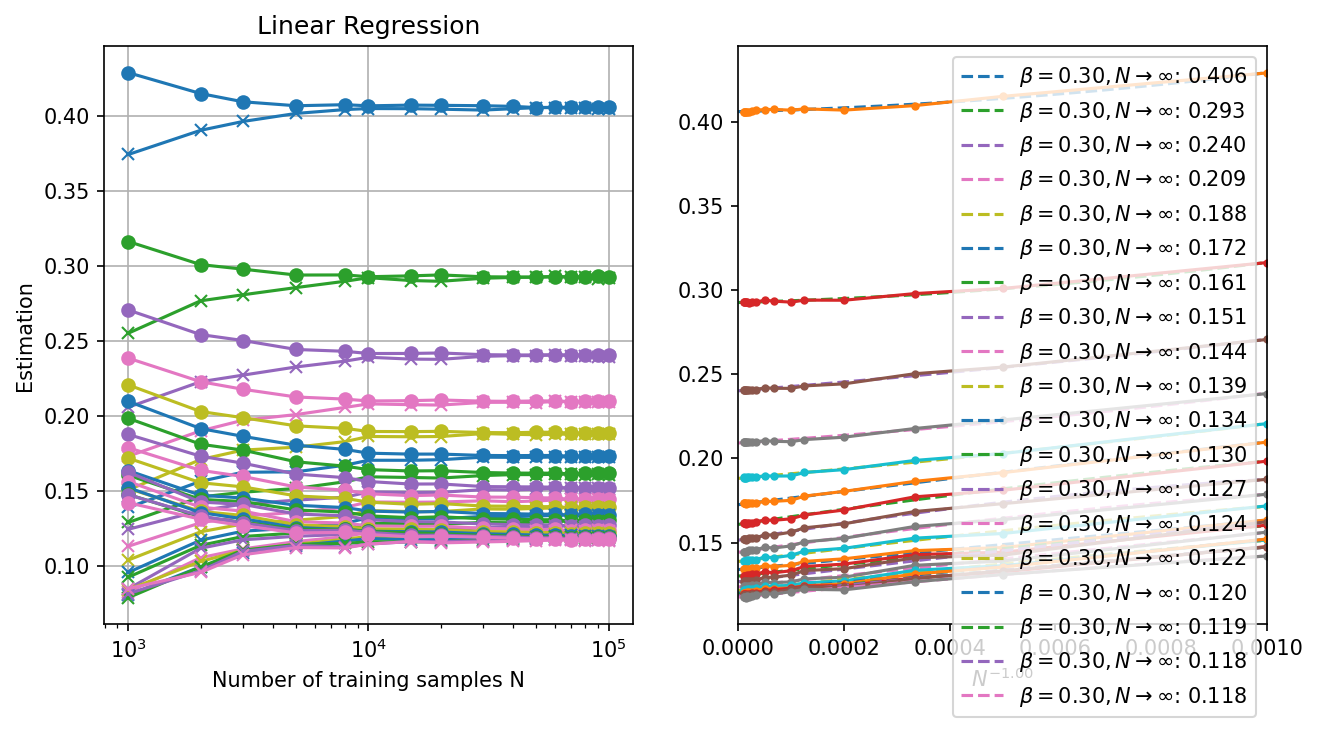

In [278]:
fig, axes = plt.subplots(1,2,figsize=(10,5))
seed = 0
N_list = [1000, 2000, 3000, 5000, 8000,10000, 15000, 20000,30000, 40000, 50000, 60000, 70000, 80000, 90000,100000]
# N_list = [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]
L = 40
print("L = ", L)
beta = 0.3
Estimated_value_list = []

r_list = np.arange(1, L//2) # distance between the two sites we want to predict

for r in r_list:
    sys_data = np.load(f"../data/Fast_CritIsing_L{L}_beta{beta}_Zoutcomes_sys.npy")
    anc_data = np.load(f"../data/Fast_CritIsing_L{L}_beta{beta}_Zoutcomes_anc.npy")
    sys_data = augment_data_Z2(sys_data, shuffle=True, seed=seed)
    anc_data = augment_data_Z2(anc_data, shuffle=True, seed=seed)
    np.random.seed(seed)
    indices = np.random.permutation(len(sys_data))

    A_list_train = []
    A_list_test = []
    for N in N_list:
        MSE_train_list = []
        MSE_test_list = []
        for i in range(L):
            X_train = anc_data[indices[:N]]
            y_train = sys_data[indices[:N], i] * sys_data[indices[:N], (i+r)%L] # Periodic boundary conditions
            
            X_test = anc_data[indices[N:2*N]]
            y_test = sys_data[indices[N:2*N], i] * sys_data[indices[N:2*N], (i+r)%L]
            
            my_model = LinearRegression(fit_intercept=True)
            my_model.fit(X_train, y_train)
            MSE_train = mean_squared_error(y_train, my_model.predict(X_train))
            MSE_train_list.append(MSE_train)
            MSE_test = mean_squared_error(y_test, my_model.predict(X_test))
            MSE_test_list.append(MSE_test)
        A_list_train.append(1-np.mean(MSE_train_list))
        A_list_test.append(1-np.mean(MSE_test_list))
    ax = axes[0]
    ax.plot(N_list, A_list_train, marker='o', label=f'L={L}')
    ax.plot(N_list, A_list_test, marker='x', label=f'L={L} (test)')
    ax.get_lines()[-1].set_color(ax.get_lines()[-2].get_color())


    ax = axes[1]
    y = np.array(A_list_train)
    x = np.array(N_list)
    powerlaw_exponent = 1.0
    x_ = 1/np.power(x,powerlaw_exponent)
    coefficients = np.polyfit(x_, y, 2)
    poly = np.poly1d(coefficients)
    x_fit = np.linspace(0, max(x_), 100)
    y_fit = poly(x_fit)
    ax.plot(x_fit, y_fit, '--', label=r'$\beta = %.2f, N\to\infty$: %.3f' % (beta, poly(0)))
    ax.plot(x_, y, '.-')
    Estimated_value_list.append(poly(0))
    print(f"Estimated value at N->infinity for beta={beta}, r={r}: {poly(0)}")
 

ax = axes[0]
ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel('Number of training samples N')
ax.set_ylabel('Estimation')
ax.set_title('Linear Regression')
ax.grid(True)

ax = axes[1]
ax.set_xlim(0, max(x_))
ax.legend()

ax.set_xlabel(r'$N^{%.2f}$' % (-powerlaw_exponent))

In [279]:
print("range of r:", r_list)
print("Estimated values at N->infinity for different r:", Estimated_value_list)

range of r: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
Estimated values at N->infinity for different r: [np.float64(0.40601581130508874), np.float64(0.29259564434865765), np.float64(0.2401267590518495), np.float64(0.2091184894240529), np.float64(0.18809267839240665), np.float64(0.17248203714825902), np.float64(0.16074464444945671), np.float64(0.15137954921471442), np.float64(0.14418520862524667), np.float64(0.13870884973023023), np.float64(0.13390827953380985), np.float64(0.13005130873005855), np.float64(0.12670082523470033), np.float64(0.12359806837925648), np.float64(0.12151817487728173), np.float64(0.11990235300967261), np.float64(0.11913504526959051), np.float64(0.11831407750200135), np.float64(0.11752784706036348)]


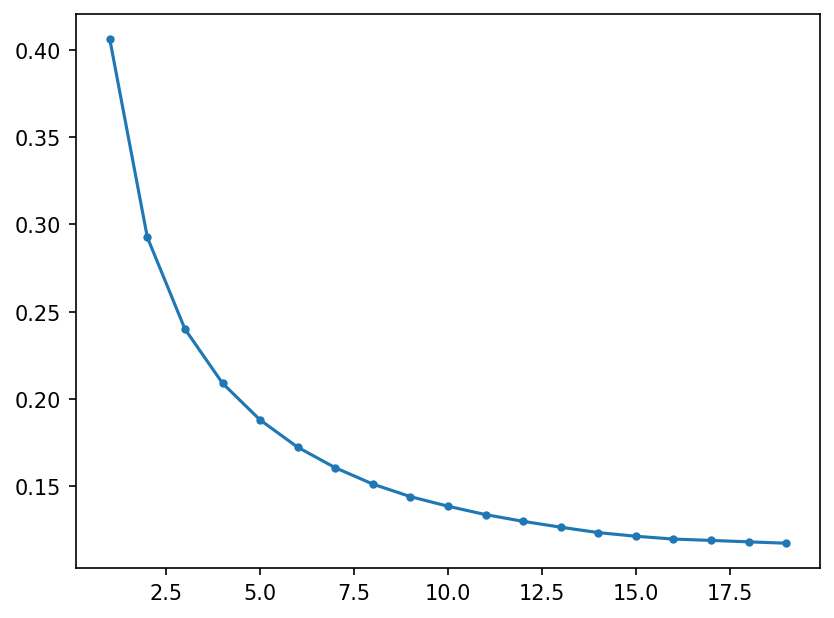

In [280]:
plt.plot(r_list, Estimated_value_list, '.-')

In [281]:
import MPSToolBox as my
r_chord = my.chord(r_list, L)
Estimated_value_list = np.array(Estimated_value_list)

np.float64(0.0021726623026586205)

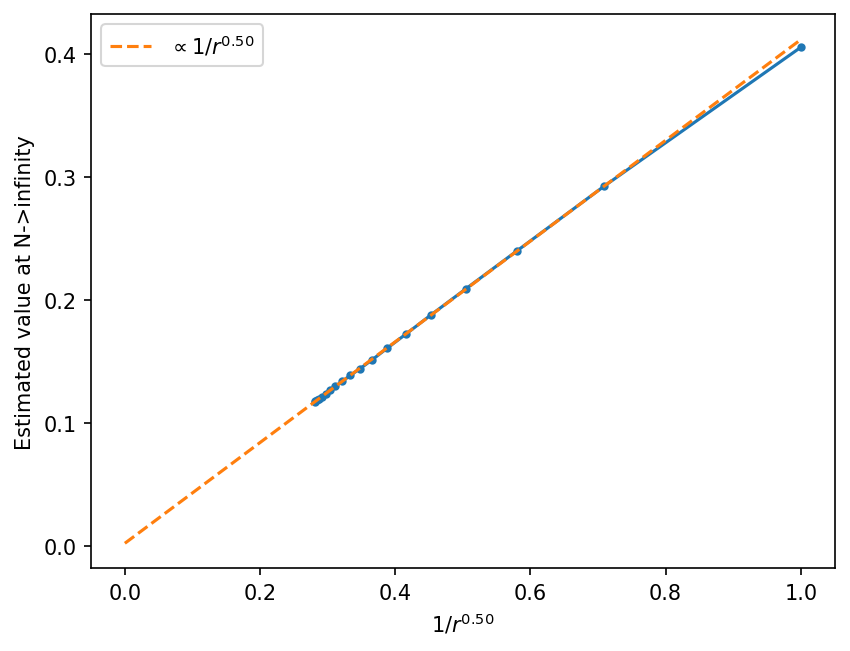

In [286]:
p = 0.5
plt.plot(1/r_chord**p, Estimated_value_list, '.-')
poly = np.poly1d(np.polyfit(1/r_chord[1:]**p, Estimated_value_list[1:], 1))
x_fit = np.linspace(0, max(1/r_chord**p), 100)
y_fit = poly(x_fit)
plt.plot(x_fit, y_fit, '--', label=r'$\propto 1/r^{%.2f}$' % p)
plt.xlabel(r'$1/r^{%.2f}$' % p)
plt.ylabel('Estimated value at N->infinity')
plt.legend()

poly.coefficients[1]

## XGBoost

L =  40
Estimated value at N->infinity for beta=0.3, r=1: 0.45378380917532485
Estimated value at N->infinity for beta=0.3, r=2: 0.36932665932063197
Estimated value at N->infinity for beta=0.3, r=3: 0.3363866203008974
Estimated value at N->infinity for beta=0.3, r=4: 0.319161347467282
Estimated value at N->infinity for beta=0.3, r=5: 0.308976707113784
Estimated value at N->infinity for beta=0.3, r=6: 0.30188160484080684
Estimated value at N->infinity for beta=0.3, r=7: 0.29700001819820304
Estimated value at N->infinity for beta=0.3, r=8: 0.29392882799987696
Estimated value at N->infinity for beta=0.3, r=9: 0.291077046599998
Estimated value at N->infinity for beta=0.3, r=10: 0.28899165231190505
Estimated value at N->infinity for beta=0.3, r=11: 0.287162947674506
Estimated value at N->infinity for beta=0.3, r=12: 0.2863481281583183
Estimated value at N->infinity for beta=0.3, r=13: 0.2851470411236741
Estimated value at N->infinity for beta=0.3, r=14: 0.28387283471831826
Estimated value at

Text(0.5, 0, '$N^{-1.00}$')

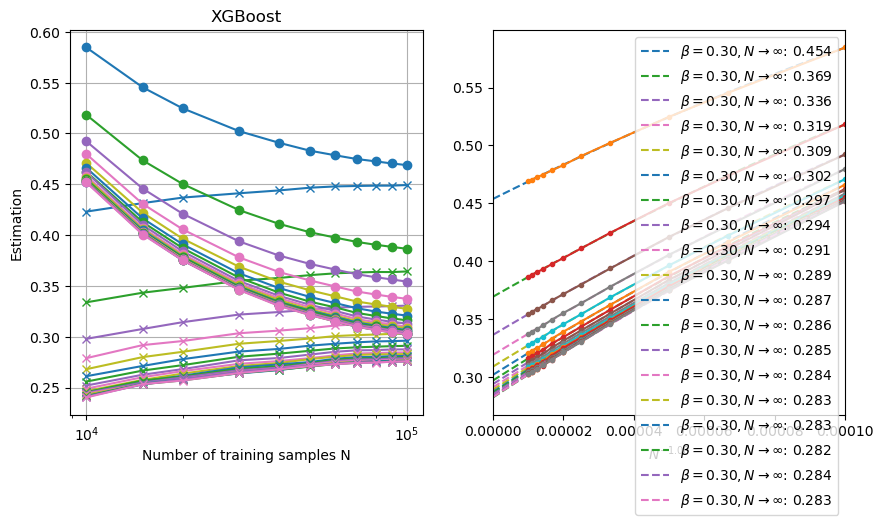

In [257]:
fig, axes = plt.subplots(1,2,figsize=(10,5))
seed = 0
N_list = [10000, 15000, 20000,30000, 40000, 50000, 60000, 70000, 80000, 90000,100000]
# N_list = [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]
L = 40
print("L = ", L)
beta = 0.3
Estimated_value_list = []

r_list = np.arange(1, L//2) # distance between the two sites we want to predict

for r in r_list:
    sys_data = np.load(f"../data/Fast_CritIsing_L{L}_beta{beta}_Zoutcomes_sys.npy")
    anc_data = np.load(f"../data/Fast_CritIsing_L{L}_beta{beta}_Zoutcomes_anc.npy")
    sys_data = augment_data_Z2(sys_data, shuffle=True, seed=seed)
    anc_data = augment_data_Z2(anc_data, shuffle=True, seed=seed)
    np.random.seed(seed)
    indices = np.random.permutation(len(sys_data))

    A_list_train = []
    A_list_test = []
    for N in N_list:
        MSE_train_list = []
        MSE_test_list = []
        for i in range(L):
            X_train = anc_data[indices[:N]]
            y_train = sys_data[indices[:N], i] * sys_data[indices[:N], (i+r)%L] # Periodic boundary conditions
            
            X_test = anc_data[indices[N:2*N]]
            y_test = sys_data[indices[N:2*N], i] * sys_data[indices[N:2*N], (i+r)%L]
            
            my_model = XGBRegressor(n_estimators=20, seed=42, max_depth=6)
            my_model.fit(X_train, y_train)
            MSE_train = mean_squared_error(y_train, my_model.predict(X_train))
            MSE_train_list.append(MSE_train)
            MSE_test = mean_squared_error(y_test, my_model.predict(X_test))
            MSE_test_list.append(MSE_test)
        A_list_train.append(1-np.mean(MSE_train_list))
        A_list_test.append(1-np.mean(MSE_test_list))
    ax = axes[0]
    ax.plot(N_list, A_list_train, marker='o', label=f'L={L}')
    ax.plot(N_list, A_list_test, marker='x', label=f'L={L} (test)')
    ax.get_lines()[-1].set_color(ax.get_lines()[-2].get_color())


    ax = axes[1]
    y = np.array(A_list_train)
    x = np.array(N_list)
    powerlaw_exponent = 1.0
    x_ = 1/np.power(x,powerlaw_exponent)
    coefficients = np.polyfit(x_, y, 2)
    poly = np.poly1d(coefficients)
    x_fit = np.linspace(0, max(x_), 100)
    y_fit = poly(x_fit)
    ax.plot(x_fit, y_fit, '--', label=r'$\beta = %.2f, N\to\infty$: %.3f' % (beta, poly(0)))
    ax.plot(x_, y, '.-')
    Estimated_value_list.append(poly(0))
    print(f"Estimated value at N->infinity for beta={beta}, r={r}: {poly(0)}")
 

ax = axes[0]
ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel('Number of training samples N')
ax.set_ylabel('Estimation')
ax.set_title('XGBoost')
ax.grid(True)

ax = axes[1]
ax.set_xlim(0, max(x_))
ax.legend()

ax.set_xlabel(r'$N^{%.2f}$' % (-powerlaw_exponent))

In [258]:
print("range of r:", r_list)
print("Estimated values at N->infinity for different r:", Estimated_value_list)

range of r: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
Estimated values at N->infinity for different r: [np.float64(0.45378380917532485), np.float64(0.36932665932063197), np.float64(0.3363866203008974), np.float64(0.319161347467282), np.float64(0.308976707113784), np.float64(0.30188160484080684), np.float64(0.29700001819820304), np.float64(0.29392882799987696), np.float64(0.291077046599998), np.float64(0.28899165231190505), np.float64(0.287162947674506), np.float64(0.2863481281583183), np.float64(0.2851470411236741), np.float64(0.28387283471831826), np.float64(0.28323107974479195), np.float64(0.28296849945687436), np.float64(0.2823458324995036), np.float64(0.28364832532953016), np.float64(0.2826838298795276)]


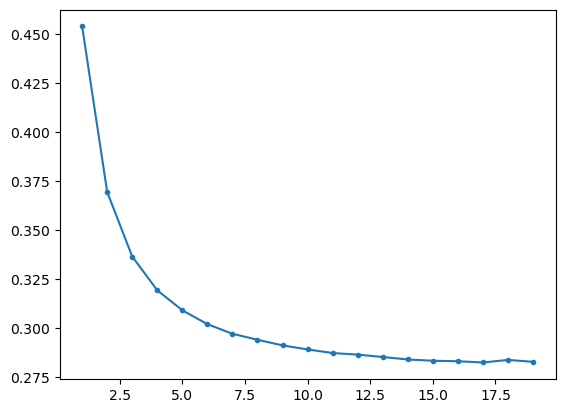

In [259]:
plt.plot(r_list, Estimated_value_list, '.-')

In [260]:
import MPSToolBox as my

Imported MPSToolBox


In [269]:
r_chord = my.chord(r_list, L)
Estimated_value_list = np.array(Estimated_value_list)

np.float64(0.2661322119392706)

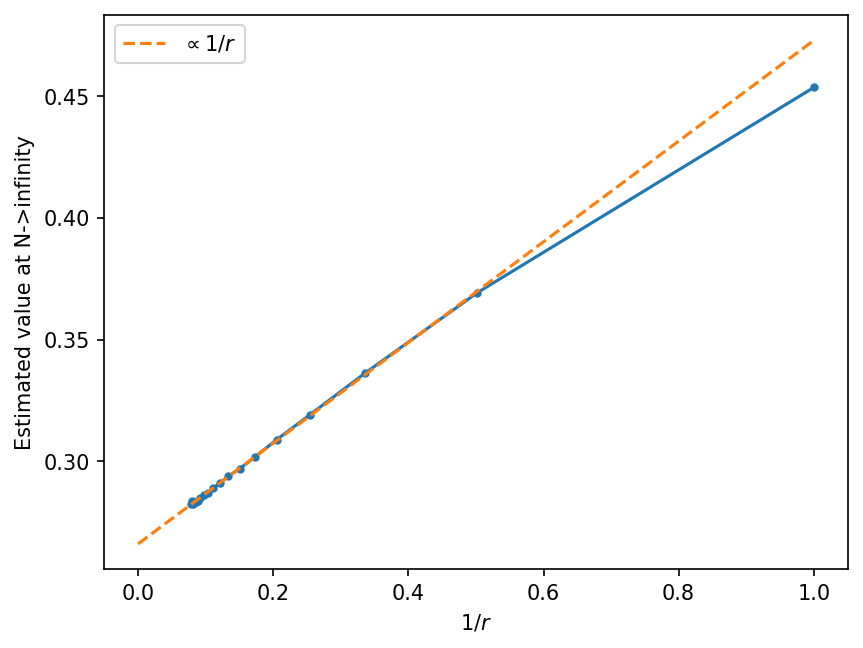

In [272]:
plt.plot(1/r_chord**1, Estimated_value_list, '.-')
poly = np.poly1d(np.polyfit(1/r_chord[1:], Estimated_value_list[1:], 1))
x_fit = np.linspace(0, max(1/r_chord), 100)
y_fit = poly(x_fit)
plt.plot(x_fit, y_fit, '--', label=r'$\propto 1/r$')
plt.xlabel(r'$1/r$')
plt.ylabel('Estimated value at N->infinity')
plt.legend()

poly.coefficients[1]

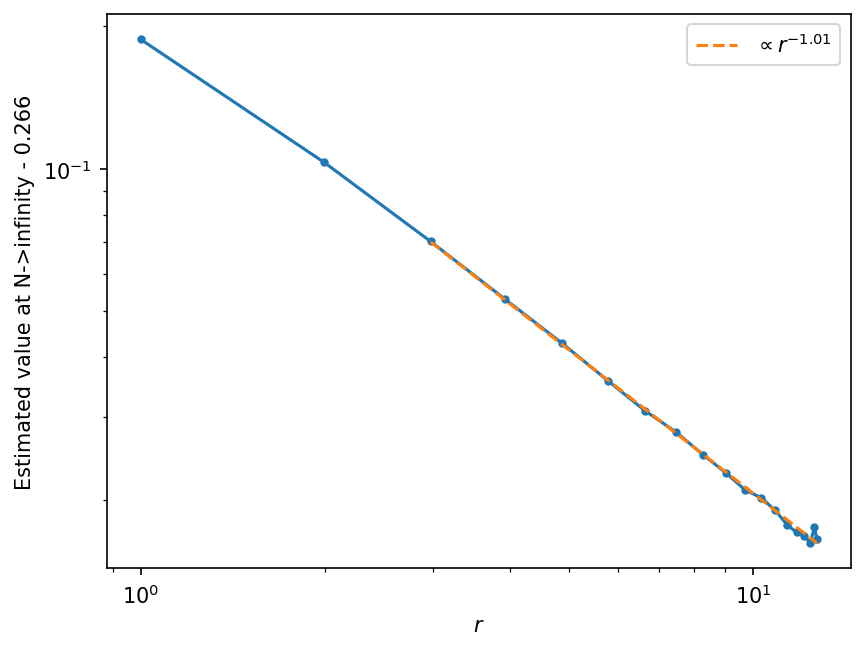

In [275]:
plt.loglog(r_chord, Estimated_value_list - 0.2661322119392706, '.-')
poly = np.poly1d(np.polyfit(np.log(r_chord[2:]), np.log(Estimated_value_list[2:] - 0.2661322119392706), 1))
x_fit = np.linspace(min(r_chord[2:]), max(r_chord), 100)
y_fit = np.exp(poly(np.log(x_fit)))
plt.plot(x_fit, y_fit, '--', label=r'$\propto r^{%.2f}$' % poly.coefficients[0])
plt.xlabel(r'$r$')
plt.ylabel('Estimated value at N->infinity - 0.266')
plt.legend()    

L =  40
Estimated value at N->infinity for beta=0.5, r=1: 0.5680608717169897
Estimated value at N->infinity for beta=0.5, r=2: 0.5287538541649471
Estimated value at N->infinity for beta=0.5, r=3: 0.5181867214618513
Estimated value at N->infinity for beta=0.5, r=4: 0.5144215060049563
Estimated value at N->infinity for beta=0.5, r=5: 0.5123205916339523
Estimated value at N->infinity for beta=0.5, r=6: 0.5111501367409419
Estimated value at N->infinity for beta=0.5, r=7: 0.5100808511667205
Estimated value at N->infinity for beta=0.5, r=8: 0.509839655233311
Estimated value at N->infinity for beta=0.5, r=9: 0.5092076275226595
Estimated value at N->infinity for beta=0.5, r=10: 0.5094276088727665
Estimated value at N->infinity for beta=0.5, r=11: 0.5089272235966108
Estimated value at N->infinity for beta=0.5, r=12: 0.5086065665232214
Estimated value at N->infinity for beta=0.5, r=13: 0.5083768553968656
Estimated value at N->infinity for beta=0.5, r=14: 0.5084141843145917
Estimated value at N->

Text(0.5, 0, '$N^{-1.00}$')

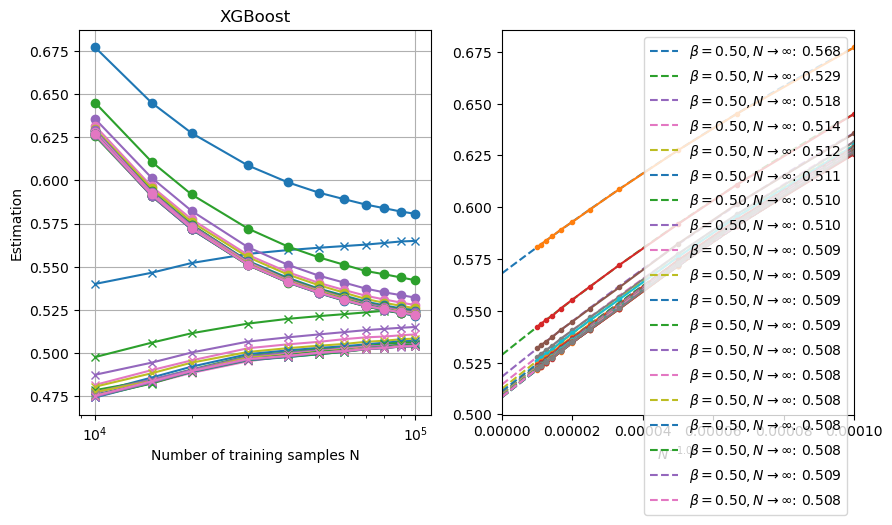

In [3]:
fig, axes = plt.subplots(1,2,figsize=(10,5))
seed = 0
N_list = [10000, 15000, 20000,30000, 40000, 50000, 60000, 70000, 80000, 90000,100000]
# N_list = [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]
L = 40
print("L = ", L)
beta = 0.5
Estimated_value_list = []

r_list = np.arange(1, L//2) # distance between the two sites we want to predict

for r in r_list:
    sys_data = np.load(f"../data/Fast_CritIsing_L{L}_beta{beta}_Zoutcomes_sys.npy")
    anc_data = np.load(f"../data/Fast_CritIsing_L{L}_beta{beta}_Zoutcomes_anc.npy")
    sys_data = augment_data_Z2(sys_data, shuffle=True, seed=seed)
    anc_data = augment_data_Z2(anc_data, shuffle=True, seed=seed)
    np.random.seed(seed)
    indices = np.random.permutation(len(sys_data))

    A_list_train = []
    A_list_test = []
    for N in N_list:
        MSE_train_list = []
        MSE_test_list = []
        for i in range(L):
            X_train = anc_data[indices[:N]]
            y_train = sys_data[indices[:N], i] * sys_data[indices[:N], (i+r)%L] # Periodic boundary conditions
            
            X_test = anc_data[indices[N:2*N]]
            y_test = sys_data[indices[N:2*N], i] * sys_data[indices[N:2*N], (i+r)%L]
            
            my_model = XGBRegressor(n_estimators=20, seed=42, max_depth=6)
            my_model.fit(X_train, y_train)
            MSE_train = mean_squared_error(y_train, my_model.predict(X_train))
            MSE_train_list.append(MSE_train)
            MSE_test = mean_squared_error(y_test, my_model.predict(X_test))
            MSE_test_list.append(MSE_test)
        A_list_train.append(1-np.mean(MSE_train_list))
        A_list_test.append(1-np.mean(MSE_test_list))
    ax = axes[0]
    ax.plot(N_list, A_list_train, marker='o', label=f'L={L}')
    ax.plot(N_list, A_list_test, marker='x', label=f'L={L} (test)')
    ax.get_lines()[-1].set_color(ax.get_lines()[-2].get_color())


    ax = axes[1]
    y = np.array(A_list_train)
    x = np.array(N_list)
    powerlaw_exponent = 1.0
    x_ = 1/np.power(x,powerlaw_exponent)
    coefficients = np.polyfit(x_, y, 2)
    poly = np.poly1d(coefficients)
    x_fit = np.linspace(0, max(x_), 100)
    y_fit = poly(x_fit)
    ax.plot(x_fit, y_fit, '--', label=r'$\beta = %.2f, N\to\infty$: %.3f' % (beta, poly(0)))
    ax.plot(x_, y, '.-')
    Estimated_value_list.append(poly(0))
    print(f"Estimated value at N->infinity for beta={beta}, r={r}: {poly(0)}")
 

ax = axes[0]
ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel('Number of training samples N')
ax.set_ylabel('Estimation')
ax.set_title('XGBoost')
ax.grid(True)

ax = axes[1]
ax.set_xlim(0, max(x_))
ax.legend()

ax.set_xlabel(r'$N^{%.2f}$' % (-powerlaw_exponent))

range of r: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
Estimated values at N->infinity for different r: [0.56806 0.52875 0.51819 0.51442 0.51232 0.51115 0.51008 0.50984 0.50921 0.50943 0.50893 0.50861
 0.50838 0.50841 0.5085  0.50821 0.50831 0.5086  0.50841]
0.506722878895713


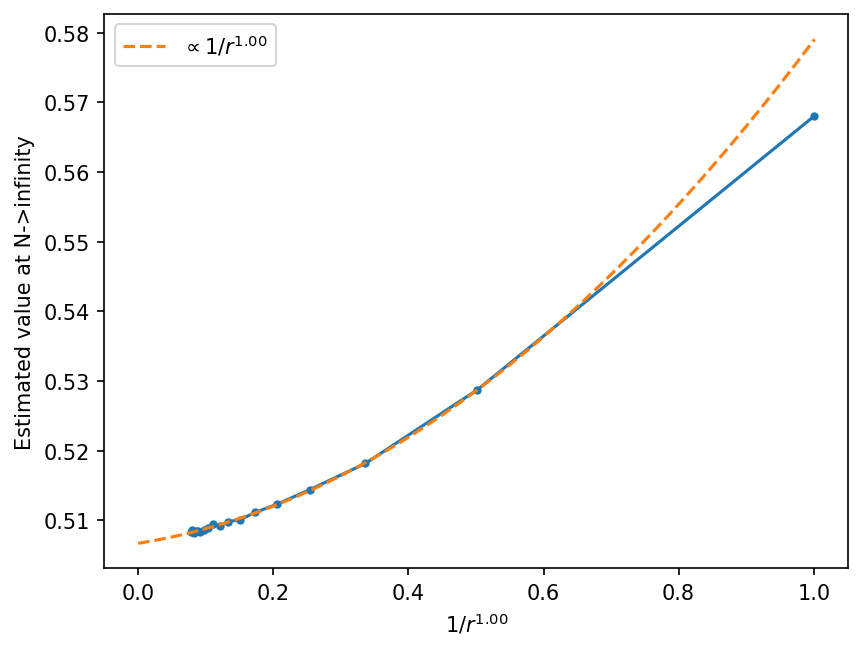

In [11]:
print("range of r:", r_list)
print("Estimated values at N->infinity for different r:", Estimated_value_list)
import MPSToolBox as my
r_chord = my.chord(r_list, L)
Estimated_value_list = np.array(Estimated_value_list)
p = 1
plt.plot(1/r_chord**p, Estimated_value_list, '.-')
poly = np.poly1d(np.polyfit(1/r_chord[1:]**p, Estimated_value_list[1:], 2))
x_fit = np.linspace(0, max(1/r_chord**p), 100)
y_fit = poly(x_fit)
plt.plot(x_fit, y_fit, '--', label=r'$\propto 1/r^{%.2f}$' % p)
plt.xlabel(r'$1/r^{%.2f}$' % p)
plt.ylabel('Estimated value at N->infinity')
plt.legend()

print(poly.coefficients[2])

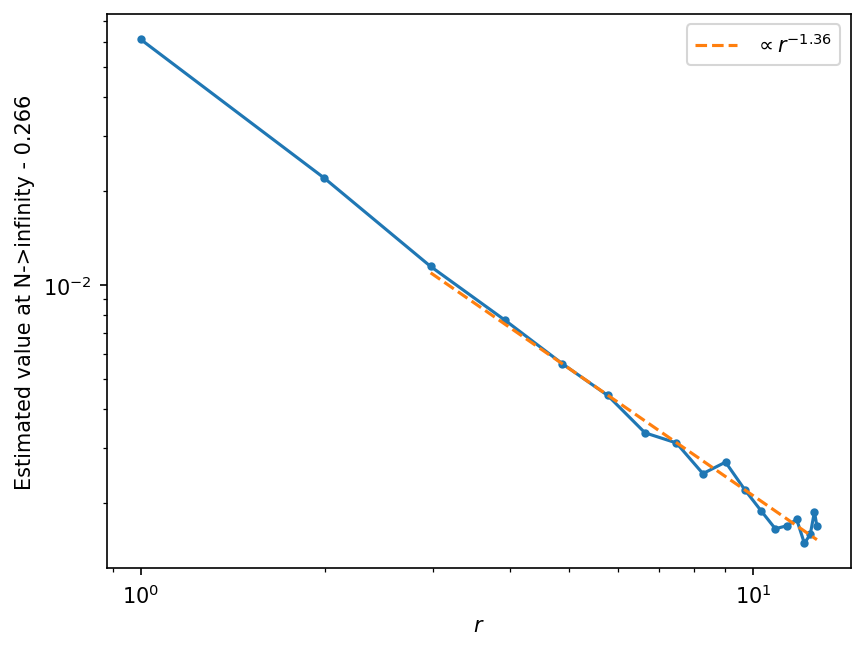

In [12]:
c = poly.coefficients[2]
plt.loglog(r_chord, Estimated_value_list - c, '.-')
poly = np.poly1d(np.polyfit(np.log(r_chord[2:]), np.log(Estimated_value_list[2:] - c), 1))
x_fit = np.linspace(min(r_chord[2:]), max(r_chord), 100)
y_fit = np.exp(poly(np.log(x_fit)))
plt.plot(x_fit, y_fit, '--', label=r'$\propto r^{%.2f}$' % poly.coefficients[0])
plt.xlabel(r'$r$')
plt.ylabel('Estimated value at N->infinity - 0.266')
plt.legend()    

L =  40
Estimated value at N->infinity for beta=0.2, r=1: 0.42263266944990524
Estimated value at N->infinity for beta=0.2, r=2: 0.3194803894302058
Estimated value at N->infinity for beta=0.2, r=3: 0.2746097522681738
Estimated value at N->infinity for beta=0.2, r=4: 0.24923427246132315
Estimated value at N->infinity for beta=0.2, r=5: 0.2328386831208467
Estimated value at N->infinity for beta=0.2, r=6: 0.22120808573135148
Estimated value at N->infinity for beta=0.2, r=7: 0.21288093888707227
Estimated value at N->infinity for beta=0.2, r=8: 0.20653898284409253
Estimated value at N->infinity for beta=0.2, r=9: 0.20180659819448368
Estimated value at N->infinity for beta=0.2, r=10: 0.19709786864755588
Estimated value at N->infinity for beta=0.2, r=11: 0.19378800338729577
Estimated value at N->infinity for beta=0.2, r=12: 0.1905167581036696
Estimated value at N->infinity for beta=0.2, r=13: 0.1882874759950082
Estimated value at N->infinity for beta=0.2, r=14: 0.18653745828845447
Estimated va

Text(0.5, 0, '$N^{-1.00}$')

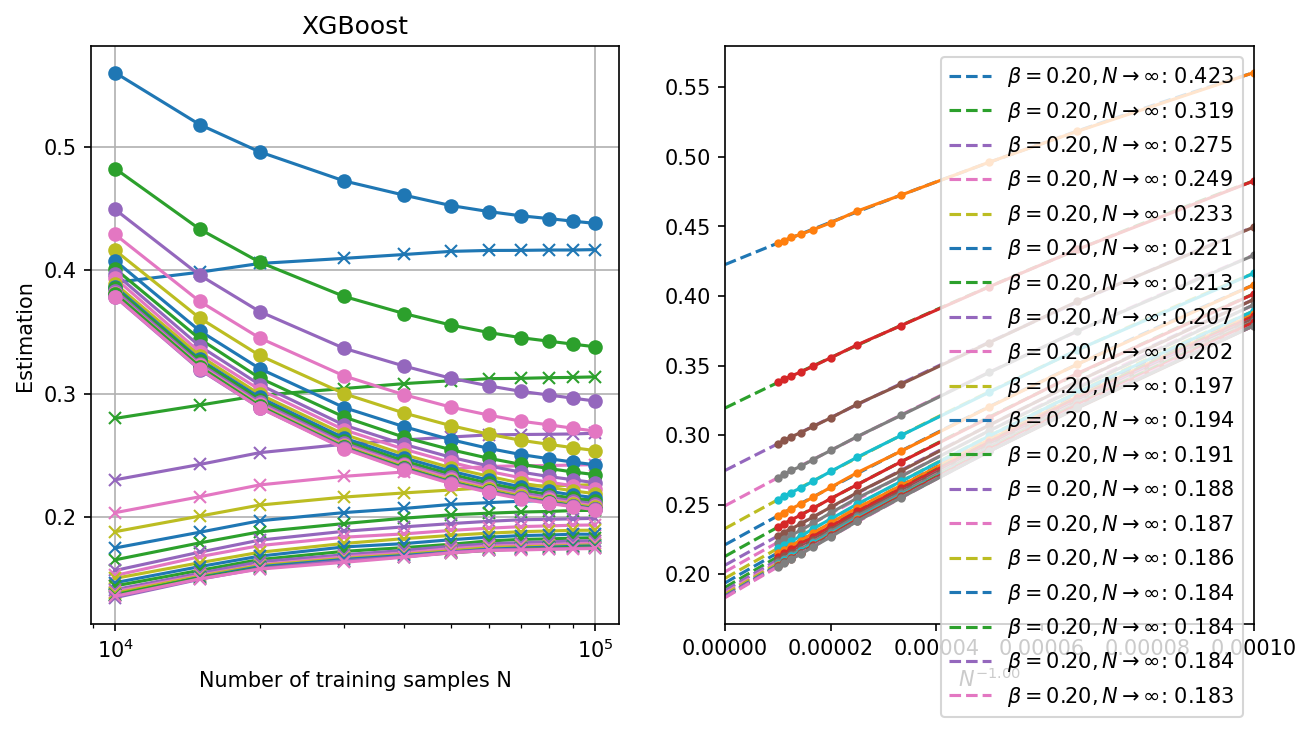

In [13]:
fig, axes = plt.subplots(1,2,figsize=(10,5))
seed = 0
N_list = [10000, 15000, 20000,30000, 40000, 50000, 60000, 70000, 80000, 90000,100000]
# N_list = [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]
L = 40
print("L = ", L)
beta = 0.2
Estimated_value_list = []

r_list = np.arange(1, L//2) # distance between the two sites we want to predict

for r in r_list:
    sys_data = np.load(f"../data/Fast_CritIsing_L{L}_beta{beta}_Zoutcomes_sys.npy")
    anc_data = np.load(f"../data/Fast_CritIsing_L{L}_beta{beta}_Zoutcomes_anc.npy")
    sys_data = augment_data_Z2(sys_data, shuffle=True, seed=seed)
    anc_data = augment_data_Z2(anc_data, shuffle=True, seed=seed)
    np.random.seed(seed)
    indices = np.random.permutation(len(sys_data))

    A_list_train = []
    A_list_test = []
    for N in N_list:
        MSE_train_list = []
        MSE_test_list = []
        for i in range(L):
            X_train = anc_data[indices[:N]]
            y_train = sys_data[indices[:N], i] * sys_data[indices[:N], (i+r)%L] # Periodic boundary conditions
            
            X_test = anc_data[indices[N:2*N]]
            y_test = sys_data[indices[N:2*N], i] * sys_data[indices[N:2*N], (i+r)%L]
            
            my_model = XGBRegressor(n_estimators=20, seed=42, max_depth=6)
            my_model.fit(X_train, y_train)
            MSE_train = mean_squared_error(y_train, my_model.predict(X_train))
            MSE_train_list.append(MSE_train)
            MSE_test = mean_squared_error(y_test, my_model.predict(X_test))
            MSE_test_list.append(MSE_test)
        A_list_train.append(1-np.mean(MSE_train_list))
        A_list_test.append(1-np.mean(MSE_test_list))
    ax = axes[0]
    ax.plot(N_list, A_list_train, marker='o', label=f'L={L}')
    ax.plot(N_list, A_list_test, marker='x', label=f'L={L} (test)')
    ax.get_lines()[-1].set_color(ax.get_lines()[-2].get_color())


    ax = axes[1]
    y = np.array(A_list_train)
    x = np.array(N_list)
    powerlaw_exponent = 1.0
    x_ = 1/np.power(x,powerlaw_exponent)
    coefficients = np.polyfit(x_, y, 2)
    poly = np.poly1d(coefficients)
    x_fit = np.linspace(0, max(x_), 100)
    y_fit = poly(x_fit)
    ax.plot(x_fit, y_fit, '--', label=r'$\beta = %.2f, N\to\infty$: %.3f' % (beta, poly(0)))
    ax.plot(x_, y, '.-')
    Estimated_value_list.append(poly(0))
    print(f"Estimated value at N->infinity for beta={beta}, r={r}: {poly(0)}")
 

ax = axes[0]
ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel('Number of training samples N')
ax.set_ylabel('Estimation')
ax.set_title('XGBoost')
ax.grid(True)

ax = axes[1]
ax.set_xlim(0, max(x_))
ax.legend()

ax.set_xlabel(r'$N^{%.2f}$' % (-powerlaw_exponent))

range of r: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
Estimated values at N->infinity for different r: [0.42263 0.31948 0.27461 0.24923 0.23284 0.22121 0.21288 0.20654 0.20181 0.1971  0.19379 0.19052
 0.18829 0.18654 0.18562 0.18433 0.18367 0.18394 0.18314]
0.14883316002182534


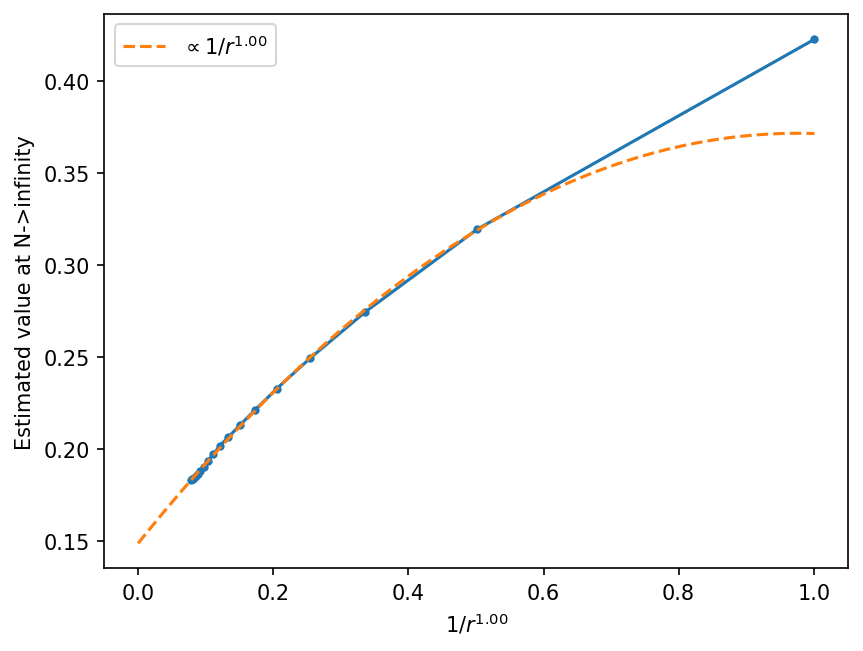

In [20]:
print("range of r:", r_list)
print("Estimated values at N->infinity for different r:", Estimated_value_list)
import MPSToolBox as my
r_chord = my.chord(r_list, L)
Estimated_value_list = np.array(Estimated_value_list)
p = 1
plt.plot(1/r_chord**p, Estimated_value_list, '.-')
poly = np.poly1d(np.polyfit(1/r_chord[1:]**p, Estimated_value_list[1:], 2))
x_fit = np.linspace(0, max(1/r_chord**p), 100)
y_fit = poly(x_fit)
plt.plot(x_fit, y_fit, '--', label=r'$\propto 1/r^{%.2f}$' % p)
plt.xlabel(r'$1/r^{%.2f}$' % p)
plt.ylabel('Estimated value at N->infinity')
plt.legend()

print(poly.coefficients[2])

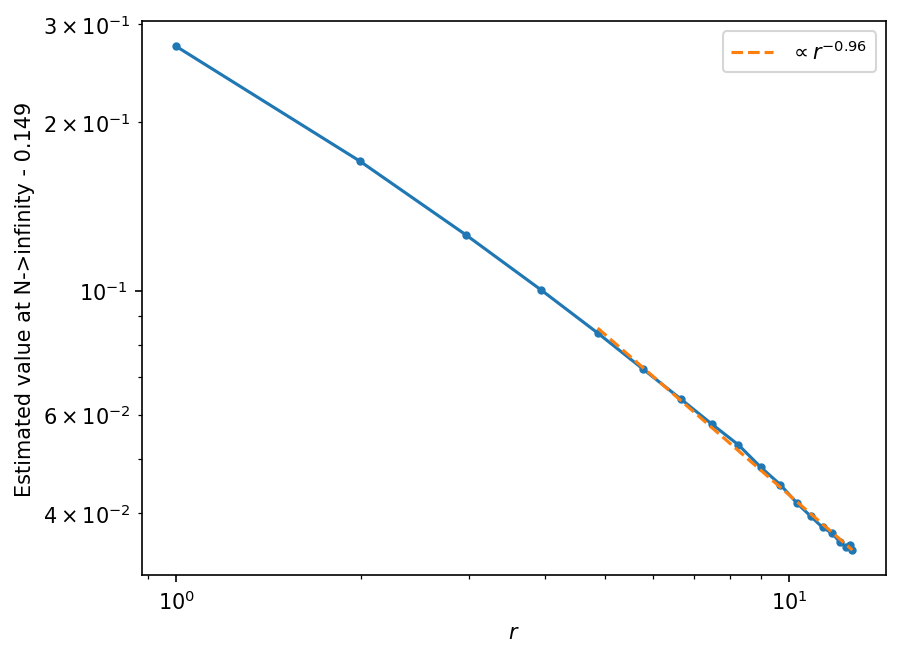

In [21]:
c = poly.coefficients[2]
plt.loglog(r_chord, Estimated_value_list - c, '.-')
poly = np.poly1d(np.polyfit(np.log(r_chord[4:]), np.log(Estimated_value_list[4:] - c), 1))
x_fit = np.linspace(min(r_chord[4:]), max(r_chord), 100)
y_fit = np.exp(poly(np.log(x_fit)))
plt.plot(x_fit, y_fit, '--', label=r'$\propto r^{%.2f}$' % poly.coefficients[0])
plt.xlabel(r'$r$')
plt.ylabel(f'Estimated value at N->infinity - {c:.3f}')
plt.legend()    

L =  16
Estimated value at N->infinity for beta=0.1, r=1: 0.4092617450039821
Estimated value at N->infinity for beta=0.1, r=2: 0.300112123924416
Estimated value at N->infinity for beta=0.1, r=3: 0.25141356119652336
Estimated value at N->infinity for beta=0.1, r=4: 0.22515944753324496
Estimated value at N->infinity for beta=0.1, r=5: 0.2097591395630235
Estimated value at N->infinity for beta=0.1, r=6: 0.1987658194161026
Estimated value at N->infinity for beta=0.1, r=7: 0.19323354323438852
[0.40926175 0.30011212 0.25141356 0.22515945 0.20975914 0.19876582
 0.19323354]


/tmp/ipykernel_4130346/3523990670.py:73: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Estimated value at N->infinity for beta=0.2, r=1: 0.4223759799379989
Estimated value at N->infinity for beta=0.2, r=2: 0.32216784253688996
Estimated value at N->infinity for beta=0.2, r=3: 0.27942255672158345
Estimated value at N->infinity for beta=0.2, r=4: 0.2560383994625663
Estimated value at N->infinity for beta=0.2, r=5: 0.24360264146537766
Estimated value at N->infinity for beta=0.2, r=6: 0.23479169998311686
Estimated value at N->infinity for beta=0.2, r=7: 0.2311416521180017
[0.42237598 0.32216784 0.27942256 0.2560384  0.24360264 0.2347917
 0.23114165]


/tmp/ipykernel_4130346/3523990670.py:73: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Estimated value at N->infinity for beta=0.3, r=1: 0.4540884167631984
Estimated value at N->infinity for beta=0.3, r=2: 0.37163568947845504
Estimated value at N->infinity for beta=0.3, r=3: 0.3400881288831689
Estimated value at N->infinity for beta=0.3, r=4: 0.324080842509888
Estimated value at N->infinity for beta=0.3, r=5: 0.3158861965664229
Estimated value at N->infinity for beta=0.3, r=6: 0.31083926607435985
Estimated value at N->infinity for beta=0.3, r=7: 0.3081146041748383
[0.45408842 0.37163569 0.34008813 0.32408084 0.3158862  0.31083927
 0.3081146 ]


...

/tmp/ipykernel_4130346/3523990670.py:73: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Estimated value at N->infinity for beta=0.8, r=1: 0.7774668857645838
Estimated value at N->infinity for beta=0.8, r=2: 0.7713825738960658
Estimated value at N->infinity for beta=0.8, r=3: 0.7711033195146604
Estimated value at N->infinity for beta=0.8, r=4: 0.7712549050678295
Estimated value at N->infinity for beta=0.8, r=5: 0.7712696361684057
Estimated value at N->infinity for beta=0.8, r=6: 0.7711968924486887
Estimated value at N->infinity for beta=0.8, r=7: 0.7710069667226241
[0.77746689 0.77138257 0.77110332 0.77125491 0.77126964 0.77119689
 0.77100697]


/tmp/ipykernel_4130346/3523990670.py:73: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Estimated value at N->infinity for beta=1.0, r=1: 0.8792420797245099
Estimated value at N->infinity for beta=1.0, r=2: 0.8779043472614431
Estimated value at N->infinity for beta=1.0, r=3: 0.8780558772517734
Estimated value at N->infinity for beta=1.0, r=4: 0.8781852671231677
Estimated value at N->infinity for beta=1.0, r=5: 0.8781529270957027
Estimated value at N->infinity for beta=1.0, r=6: 0.878027097064442
Estimated value at N->infinity for beta=1.0, r=7: 0.8782136405532353
[0.87924208 0.87790435 0.87805588 0.87818527 0.87815293 0.8780271
 0.87821364]


/tmp/ipykernel_4130346/3523990670.py:73: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


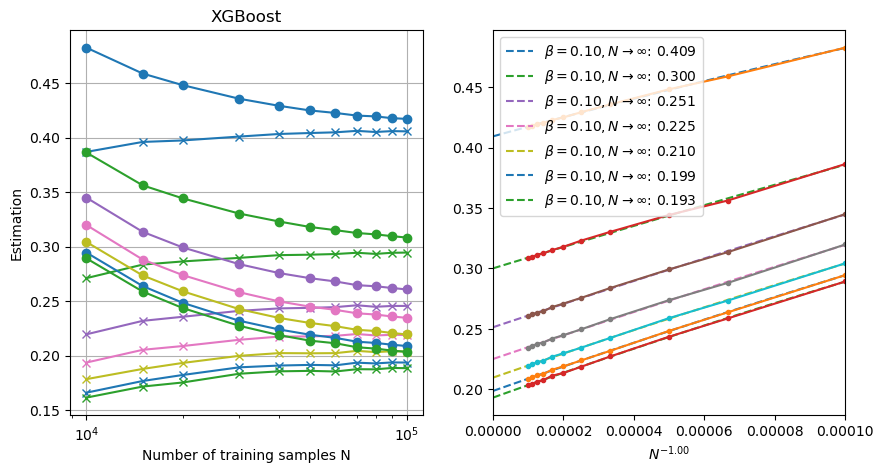

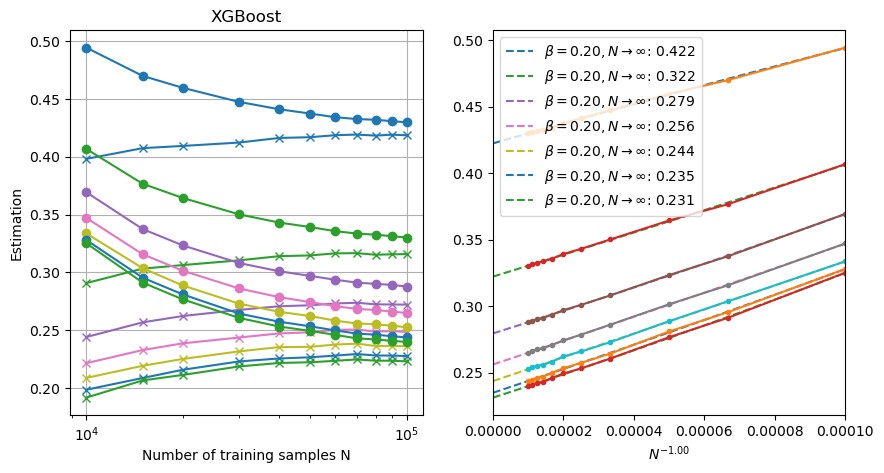

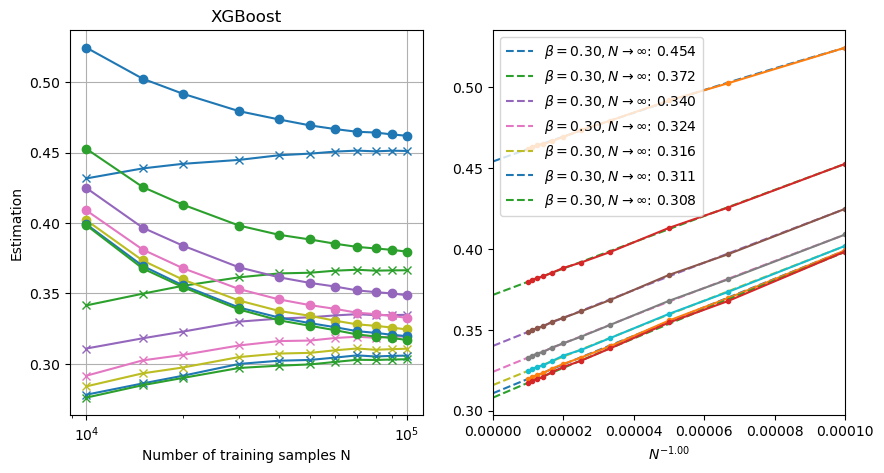

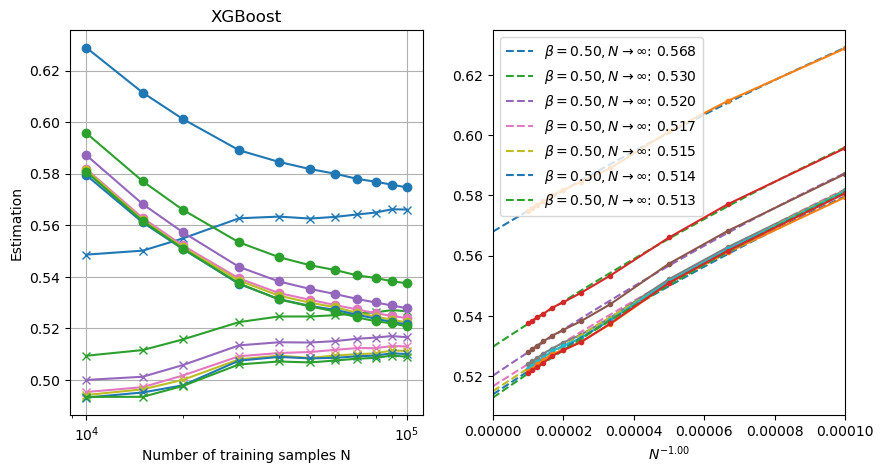

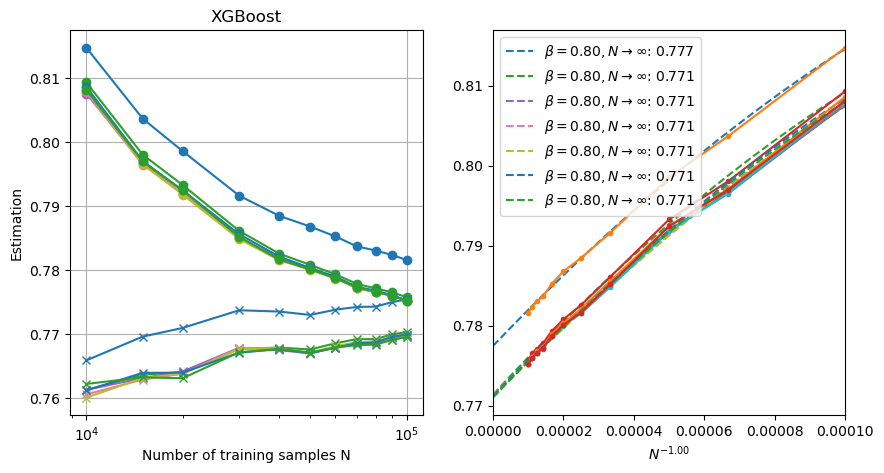

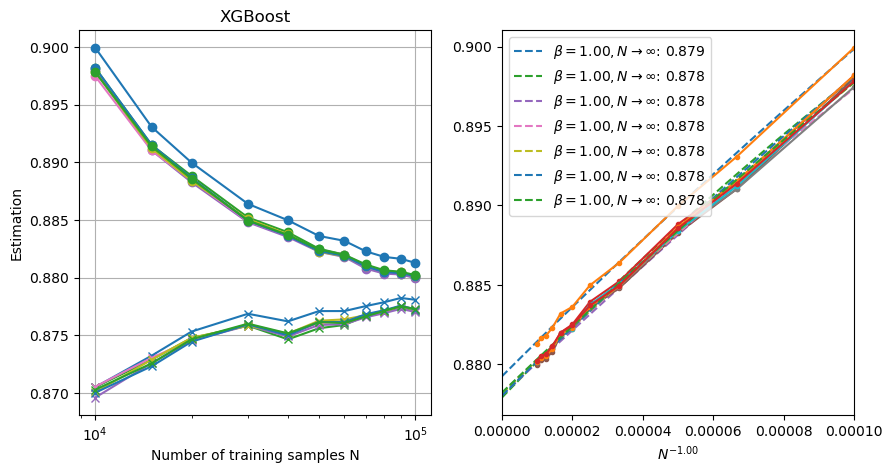

In [4]:
seed = 0
N_list = [10000, 15000, 20000,30000, 40000, 50000, 60000, 70000, 80000, 90000,100000]
# N_list = [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]
L = 16
print("L = ", L)
beta = 0.2

r_list = np.arange(1, L//2) # distance between the two sites we want to predict
for beta in [0.1, 0.2, 0.3, 0.5, 0.8, 1.0]:
    Estimated_value_list = []
    fig, axes = plt.subplots(1,2,figsize=(10,5))
    for r in r_list:
        sys_data = np.load(f"../data/Fast_CritIsing_L{L}_beta{beta}_Zoutcomes_sys.npy")
        anc_data = np.load(f"../data/Fast_CritIsing_L{L}_beta{beta}_Zoutcomes_anc.npy")
        sys_data = augment_data_Z2(sys_data, shuffle=True, seed=seed)
        anc_data = augment_data_Z2(anc_data, shuffle=True, seed=seed)
        np.random.seed(seed)
        indices = np.random.permutation(len(sys_data))

        A_list_train = []
        A_list_test = []
        for N in N_list:
            MSE_train_list = []
            MSE_test_list = []
            for i in range(L):
                X_train = anc_data[indices[:N]]
                y_train = sys_data[indices[:N], i] * sys_data[indices[:N], (i+r)%L] # Periodic boundary conditions
                
                X_test = anc_data[indices[N:2*N]]
                y_test = sys_data[indices[N:2*N], i] * sys_data[indices[N:2*N], (i+r)%L]
                
                my_model = XGBRegressor(n_estimators=20, seed=42, max_depth=6)
                my_model.fit(X_train, y_train)
                MSE_train = mean_squared_error(y_train, my_model.predict(X_train))
                MSE_train_list.append(MSE_train)
                MSE_test = mean_squared_error(y_test, my_model.predict(X_test))
                MSE_test_list.append(MSE_test)
            A_list_train.append(1-np.mean(MSE_train_list))
            A_list_test.append(1-np.mean(MSE_test_list))
        ax = axes[0]
        ax.plot(N_list, A_list_train, marker='o', label=f'L={L}')
        ax.plot(N_list, A_list_test, marker='x', label=f'L={L} (test)')
        ax.get_lines()[-1].set_color(ax.get_lines()[-2].get_color())


        ax = axes[1]
        y = np.array(A_list_train)
        x = np.array(N_list)
        powerlaw_exponent = 1.0
        x_ = 1/np.power(x,powerlaw_exponent)
        coefficients = np.polyfit(x_, y, 2)
        poly = np.poly1d(coefficients)
        x_fit = np.linspace(0, max(x_), 100)
        y_fit = poly(x_fit)
        ax.plot(x_fit, y_fit, '--', label=r'$\beta = %.2f, N\to\infty$: %.3f' % (beta, poly(0)))
        ax.plot(x_, y, '.-')
        Estimated_value_list.append(poly(0))
        print(f"Estimated value at N->infinity for beta={beta}, r={r}: {poly(0)}")

    ax = axes[0]
    ax.set_xscale('log')
    # ax.set_yscale('log')
    ax.set_xlabel('Number of training samples N')
    ax.set_ylabel('Estimation')
    ax.set_title('XGBoost')
    ax.grid(True)

    ax = axes[1]
    ax.set_xlim(0, max(x_))
    ax.legend()

    ax.set_xlabel(r'$N^{%.2f}$' % (-powerlaw_exponent))
    fig.show()
    print(np.array(Estimated_value_list))
    np.save(f"temp/CritIsing_L{L}_beta{beta}_Z_2pt_second_moment_xgboost.npy", np.array(Estimated_value_list))

In [ ]:
fig = plt.plot(figsize=(8, 5))
ax = plt.gca()

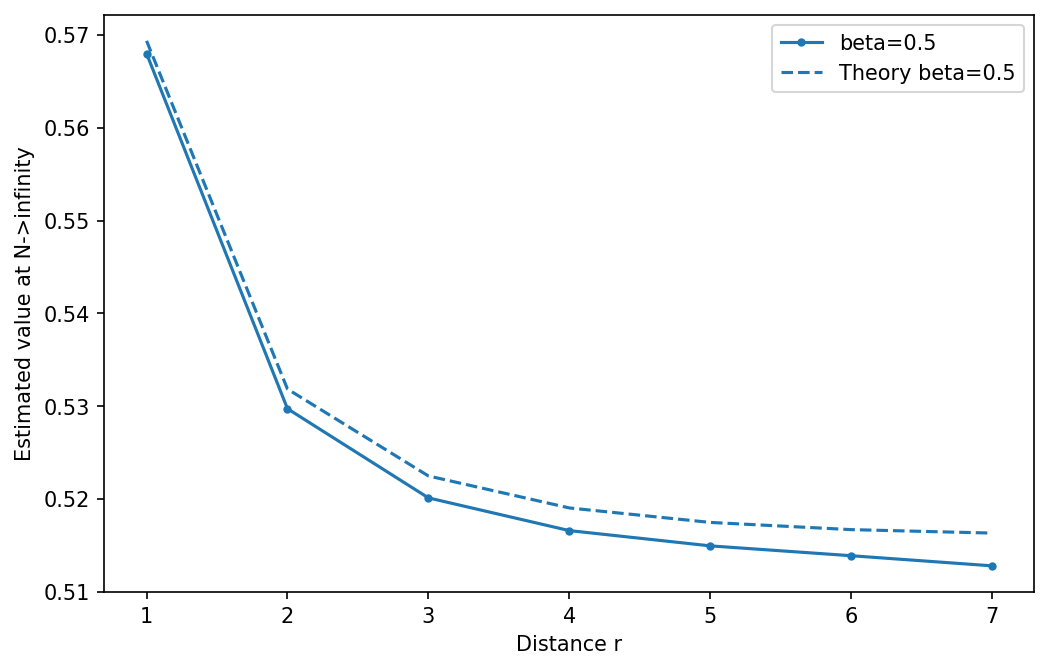

In [56]:
fig = plt.figure(figsize=(8, 5))
ax = plt.gca()
beta_list = [0.5]
for beta in beta_list:
    Estimated_value_list = np.load(f"temp/CritIsing_L{L}_beta{beta}_Z_2pt_second_moment_xgboost.npy")
    r_list = np.arange(1, L//2)
    ax.plot(r_list, Estimated_value_list, '.-', label=f'beta={beta}')
    
    Theory_value_list = np.load(f"temp/CritIsing_L{L}_beta{beta}_Z_2pt_second_moment_theory.npy")
    ax.plot(r_list, Theory_value_list, '--', label=f'Theory beta={beta}')
    
    # set the same color for the theory and estimated values
    ax.get_lines()[-1].set_color(ax.get_lines()[-2].get_color())
    
ax.set_xlabel('Distance r')
ax.set_ylabel('Estimated value at N->infinity')
ax.legend()

# TODO: check with ED.

In [1]:
from exactdiagonalization import *
from utils import weak_measurement_pauli, sZ, sX
L_list = [14] # 8, 10, 12, 14, 16, 18, 20
beta_list = [0.3] # 0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.5, 0.8, 1.0

for L in L_list:
    wavefunction = np.load('../data/CritIsing_L'+str(L)+'_ground_state.npy')
    for beta in beta_list:
        results_z = []
        results_x = []
        for r in range(1, L):
            ops = [(sZ, 0), (sZ, r)]
            povm = weak_measurement_pauli(sZ, beta=beta, real=True)
            povm_list = [povm] * L
            site_ind = np.arange(L)
            altered_moment = measurement_altered_moments(wavefunction, k=2, povm_list=povm_list, site_ind=site_ind, ops=ops)
            results_z.append(altered_moment)
            print(f"L = {L}, beta = {beta}: Measurement-altered Z second moment for r={r}: {altered_moment}")
            
            ops = [(sX, 0), (sX, r)]
            povm = weak_measurement_pauli(sX, beta=beta, real=True)
            povm_list = [povm] * L
            site_ind = np.arange(L)
            altered_moment = measurement_altered_moments(wavefunction, k=2, povm_list=povm_list, site_ind=site_ind, ops=ops)
            results_x.append(altered_moment)
            print(f"L = {L}, beta = {beta}: Measurement-altered X second moment for r={r}: {altered_moment}")
            
        results_z = np.array(results_z)
        results_x = np.array(results_x)
        np.save('temp/CritIsing_L'+str(L)+'_beta'+str(beta)+'_Z_2pt_second_moment_theory.npy', results_z)
        np.save('temp/CritIsing_L'+str(L)+'_beta'+str(beta)+'_X_2pt_second_moment_theory.npy', results_x)

L = 14, beta = 0.3: Measurement-altered Z second moment for r=1: 0.4542238156730867
L = 14, beta = 0.3: Measurement-altered X second moment for r=1: 0.38204786404276075
L = 14, beta = 0.3: Measurement-altered Z second moment for r=2: 0.37186779534871994
L = 14, beta = 0.3: Measurement-altered X second moment for r=2: 0.31156723971487754
L = 14, beta = 0.3: Measurement-altered Z second moment for r=3: 0.3409013152839073
L = 14, beta = 0.3: Measurement-altered X second moment for r=3: 0.29776382247878286
L = 14, beta = 0.3: Measurement-altered Z second moment for r=4: 0.32589024088732976
L = 14, beta = 0.3: Measurement-altered X second moment for r=4: 0.29349812837955835
L = 14, beta = 0.3: Measurement-altered Z second moment for r=5: 0.3179696973861227
L = 14, beta = 0.3: Measurement-altered X second moment for r=5: 0.2917930684667601
L = 14, beta = 0.3: Measurement-altered Z second moment for r=6: 0.3140149044046096
L = 14, beta = 0.3: Measurement-altered X second moment for r=6: 0.291

In [2]:
from exactdiagonalization import *
from utils import weak_measurement_pauli, sZ, sX
L_list = [16] # 8, 10, 12, 14, 16, 18, 20
beta_list = [0.3] # 0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.5, 0.8, 1.0

for L in L_list:
    wavefunction = np.load('../data/CritIsing_L'+str(L)+'_ground_state.npy')
    for beta in beta_list:
        results_z = []
        results_x = []
        for r in range(1, L):
            ops = [(sZ, 0), (sZ, r)]
            povm = weak_measurement_pauli(sZ, beta=beta, real=True)
            povm_list = [povm] * L
            site_ind = np.arange(L)
            altered_moment = measurement_altered_moments(wavefunction, k=2, povm_list=povm_list, site_ind=site_ind, ops=ops)
            results_z.append(altered_moment)
            print(f"L = {L}, beta = {beta}: Measurement-altered Z second moment for r={r}: {altered_moment}")
            
            ops = [(sX, 0), (sX, r)]
            povm = weak_measurement_pauli(sX, beta=beta, real=True)
            povm_list = [povm] * L
            site_ind = np.arange(L)
            altered_moment = measurement_altered_moments(wavefunction, k=2, povm_list=povm_list, site_ind=site_ind, ops=ops)
            results_x.append(altered_moment)
            print(f"L = {L}, beta = {beta}: Measurement-altered X second moment for r={r}: {altered_moment}")
            
        results_z = np.array(results_z)
        results_x = np.array(results_x)
        np.save('temp/CritIsing_L'+str(L)+'_beta'+str(beta)+'_Z_2pt_second_moment_theory.npy', results_z)
        np.save('temp/CritIsing_L'+str(L)+'_beta'+str(beta)+'_X_2pt_second_moment_theory.npy', results_x)

L = 16, beta = 0.3: Measurement-altered Z second moment for r=1: 0.4545139809378551
L = 16, beta = 0.3: Measurement-altered X second moment for r=1: 0.38067501248712443
L = 16, beta = 0.3: Measurement-altered Z second moment for r=2: 0.372257263955422
L = 16, beta = 0.3: Measurement-altered X second moment for r=2: 0.31051874913572297
L = 16, beta = 0.3: Measurement-altered Z second moment for r=3: 0.3411717400031289
L = 16, beta = 0.3: Measurement-altered X second moment for r=3: 0.2968106265829625
L = 16, beta = 0.3: Measurement-altered Z second moment for r=4: 0.3258409231899139
L = 16, beta = 0.3: Measurement-altered X second moment for r=4: 0.29254665373493616
L = 16, beta = 0.3: Measurement-altered Z second moment for r=5: 0.31737194435424665
L = 16, beta = 0.3: Measurement-altered X second moment for r=5: 0.2907892657814691
L = 16, beta = 0.3: Measurement-altered Z second moment for r=6: 0.3125673233446235
L = 16, beta = 0.3: Measurement-altered X second moment for r=6: 0.289955

In [2]:
from exactdiagonalization import *
from utils import weak_measurement_pauli, sZ, sX
L_list = [16] # 8, 10, 12, 14, 16, 18, 20
beta_list = [0.2, 0.3, 0.5, 0.1, 0.8, 1.0] # 0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.5, 0.8, 1.0

for L in L_list:
    wavefunction = np.load('../data/CritIsing_L'+str(L)+'_ground_state.npy')
    for beta in beta_list:
        results_z = []
        results_x = []
        for r in range(1, L//2):
            ops = [(sZ, 0), (sZ, r)]
            povm = weak_measurement_pauli(sZ, beta=beta, real=True)
            povm_list = [povm] * L
            site_ind = np.arange(L)
            altered_moment = measurement_altered_moments(wavefunction, k=2, povm_list=povm_list, site_ind=site_ind, ops=ops)
            results_z.append(altered_moment)
            print(f"L = {L}, beta = {beta}: Measurement-altered Z second moment for r={r}: {altered_moment}")
            
            # ops = [(sX, 0), (sX, r)]
            # povm = weak_measurement_pauli(sX, beta=beta, real=True)
            # povm_list = [povm] * L
            # site_ind = np.arange(L)
            # altered_moment = measurement_altered_moments(wavefunction, k=2, povm_list=povm_list, site_ind=site_ind, ops=ops)
            # results_x.append(altered_moment)
            # print(f"L = {L}, beta = {beta}: Measurement-altered X second moment for r={r}: {altered_moment}")
            
        results_z = np.array(results_z)
        # results_x = np.array(results_x)
        np.save('temp/CritIsing_L'+str(L)+'_beta'+str(beta)+'_Z_2pt_second_moment_theory.npy', results_z)
        # np.save('temp/CritIsing_L'+str(L)+'_beta'+str(beta)+'_X_2pt_second_moment_theory.npy', results_x)

L = 16, beta = 0.2: Measurement-altered Z second moment for r=1: 0.4219685911370733
L = 16, beta = 0.2: Measurement-altered Z second moment for r=2: 0.32111151911363367
L = 16, beta = 0.2: Measurement-altered Z second moment for r=3: 0.2783857071860517
L = 16, beta = 0.2: Measurement-altered Z second moment for r=4: 0.2553249852944703
L = 16, beta = 0.2: Measurement-altered Z second moment for r=5: 0.24167774491858468
L = 16, beta = 0.2: Measurement-altered Z second moment for r=6: 0.23354042969023145
L = 16, beta = 0.2: Measurement-altered Z second moment for r=7: 0.2291717345479366
L = 16, beta = 0.3: Measurement-altered Z second moment for r=1: 0.4545139809378551
L = 16, beta = 0.3: Measurement-altered Z second moment for r=2: 0.372257263955422
L = 16, beta = 0.3: Measurement-altered Z second moment for r=3: 0.3411717400031289
L = 16, beta = 0.3: Measurement-altered Z second moment for r=4: 0.3258409231899139
L = 16, beta = 0.3: Measurement-altered Z second moment for r=5: 0.3173719

In [1]:
from exactdiagonalization import *
from utils import weak_measurement_pauli, sZ, sX
L_list = [16] # 8, 10, 12, 14, 16, 18, 20
beta_list = [0.05, 0.4, 0.03, 0.02, 0.01] # 0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.5, 0.8, 1.0

for L in L_list:
    wavefunction = np.load('../data/CritIsing_L'+str(L)+'_ground_state.npy')
    for beta in beta_list:
        results_z = []
        results_x = []
        for r in range(1, L//2):
            ops = [(sZ, 0), (sZ, r)]
            povm = weak_measurement_pauli(sZ, beta=beta, real=True)
            povm_list = [povm] * L
            site_ind = np.arange(L)
            altered_moment = measurement_altered_moments(wavefunction, k=2, povm_list=povm_list, site_ind=site_ind, ops=ops)
            results_z.append(altered_moment)
            print(f"L = {L}, beta = {beta}: Measurement-altered Z second moment for r={r}: {altered_moment}")
            
            # ops = [(sX, 0), (sX, r)]
            # povm = weak_measurement_pauli(sX, beta=beta, real=True)
            # povm_list = [povm] * L
            # site_ind = np.arange(L)
            # altered_moment = measurement_altered_moments(wavefunction, k=2, povm_list=povm_list, site_ind=site_ind, ops=ops)
            # results_x.append(altered_moment)
            # print(f"L = {L}, beta = {beta}: Measurement-altered X second moment for r={r}: {altered_moment}")
            
        results_z = np.array(results_z)
        # results_x = np.array(results_x)
        np.save('temp/CritIsing_L'+str(L)+'_beta'+str(beta)+'_Z_2pt_second_moment_theory.npy', results_z)
        # np.save('temp/CritIsing_L'+str(L)+'_beta'+str(beta)+'_X_2pt_second_moment_theory.npy', results_x)

L = 16, beta = 0.05: Measurement-altered Z second moment for r=1: 0.4067131374701915
L = 16, beta = 0.05: Measurement-altered Z second moment for r=2: 0.2960140838693019
L = 16, beta = 0.05: Measurement-altered Z second moment for r=3: 0.24675303358209133
L = 16, beta = 0.05: Measurement-altered Z second moment for r=4: 0.21910685188734141
L = 16, beta = 0.05: Measurement-altered Z second moment for r=5: 0.20224319486187864
L = 16, beta = 0.05: Measurement-altered Z second moment for r=6: 0.19196232186743784
L = 16, beta = 0.05: Measurement-altered Z second moment for r=7: 0.18636176909185947
L = 16, beta = 0.4: Measurement-altered Z second moment for r=1: 0.5050899685531016
L = 16, beta = 0.4: Measurement-altered Z second moment for r=2: 0.4460431091056236
L = 16, beta = 0.4: Measurement-altered Z second moment for r=3: 0.42746171475891703
L = 16, beta = 0.4: Measurement-altered Z second moment for r=4: 0.4194710625016532
L = 16, beta = 0.4: Measurement-altered Z second moment for r=5

In [1]:
from exactdiagonalization import *
from utils import weak_measurement_pauli, sZ, sX
L_list = [16] # 8, 10, 12, 14, 16, 18, 20
beta_list = [0.8, 1.0, 1.2, 1.5, 2.0] # 0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.5, 0.8, 1.0

for L in L_list:
    wavefunction = np.load('../data/CritIsing_L'+str(L)+'_ground_state.npy')
    for beta in beta_list:
        results_z = []
        results_x = []
        for r in range(1, L//2+1):
            ops = [(sZ, 0), (sZ, r)]
            povm = weak_measurement_pauli(sZ, beta=beta, real=True)
            povm_list = [povm] * L
            site_ind = np.arange(L)
            altered_moment = measurement_altered_moments(wavefunction, k=2, povm_list=povm_list, site_ind=site_ind, ops=ops)
            results_z.append(altered_moment)
            print(f"L = {L}, beta = {beta}: Measurement-altered Z second moment for r={r}: {altered_moment}")
            
            # ops = [(sX, 0), (sX, r)]
            # povm = weak_measurement_pauli(sX, beta=beta, real=True)
            # povm_list = [povm] * L
            # site_ind = np.arange(L)
            # altered_moment = measurement_altered_moments(wavefunction, k=2, povm_list=povm_list, site_ind=site_ind, ops=ops)
            # results_x.append(altered_moment)
            # print(f"L = {L}, beta = {beta}: Measurement-altered X second moment for r={r}: {altered_moment}")
            
        results_z = np.array(results_z)
        # results_x = np.array(results_x)
        np.save('temp/CritIsing_L'+str(L)+'_beta'+str(beta)+'_Z_2pt_second_moment_theory.npy', results_z)
        # np.save('temp/CritIsing_L'+str(L)+'_beta'+str(beta)+'_X_2pt_second_moment_theory.npy', results_x)

L = 16, beta = 0.8: Measurement-altered Z second moment for r=1: 0.7775472640241217
L = 16, beta = 0.8: Measurement-altered Z second moment for r=2: 0.7724158350722345
L = 16, beta = 0.8: Measurement-altered Z second moment for r=3: 0.7718991131875589
L = 16, beta = 0.8: Measurement-altered Z second moment for r=4: 0.7717746390914735
L = 16, beta = 0.8: Measurement-altered Z second moment for r=5: 0.7717277960055348
L = 16, beta = 0.8: Measurement-altered Z second moment for r=6: 0.771706651602497
L = 16, beta = 0.8: Measurement-altered Z second moment for r=7: 0.7716969865778459
L = 16, beta = 0.8: Measurement-altered Z second moment for r=8: 0.7716941509671829
L = 16, beta = 1.0: Measurement-altered Z second moment for r=1: 0.8791276470606978
L = 16, beta = 1.0: Measurement-altered Z second moment for r=2: 0.8781640423926076
L = 16, beta = 1.0: Measurement-altered Z second moment for r=3: 0.8781440917595422
L = 16, beta = 1.0: Measurement-altered Z second moment for r=4: 0.8781429145

In [1]:
import sklearn
import numpy as np
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

range of r: [1 2 3 4 5 6 7]
Estimated values at N->infinity for different r: [0.87913 0.87816 0.87814 0.87814 0.87814 0.87814 0.87814]
[0.8791276470606978, 0.8781640423926076, 0.8781440917595422, 0.8781429145709254, 0.878142847980184, 0.8781428401531666, 0.8781428273259488]
0.8782756780249062
[ 0.00052 -0.00053  0.87828]


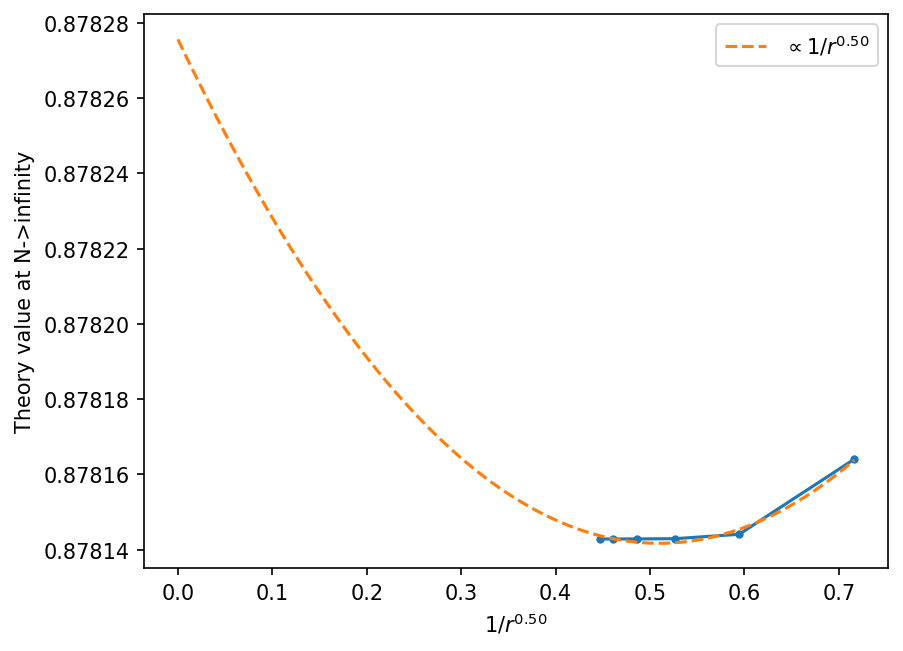

In [88]:
L = 16
beta = 1.0
r_list = np.arange(1, L//2)
Theory_value_list = np.load(f"temp/CritIsing_L{L}_beta{beta}_Z_2pt_second_moment_theory.npy")
print("range of r:", r_list)
print("Estimated values at N->infinity for different r:", Theory_value_list)
import MPSToolBox as my
r_chord = my.chord(r_list, L)
Theory_value_list = np.array(Theory_value_list)
print(Theory_value_list.tolist())
p = 0.5
plt.plot(1/r_chord[1:]**p, Theory_value_list[1:], '.-')
poly = np.poly1d(np.polyfit(1/r_chord[1:]**p, Theory_value_list[1:], 2))
x_fit = np.linspace(0, max(1/r_chord[1:]**p), 100)
y_fit = poly(x_fit)
plt.plot(x_fit, y_fit, '--', label=r'$\propto 1/r^{%.2f}$' % p)
plt.xlabel(r'$1/r^{%.2f}$' % p)
plt.ylabel('Theory value at N->infinity')
plt.legend()

print(poly.coefficients[2])
print(poly.coefficients)

In [91]:
x = r_chord
y = Theory_value_list

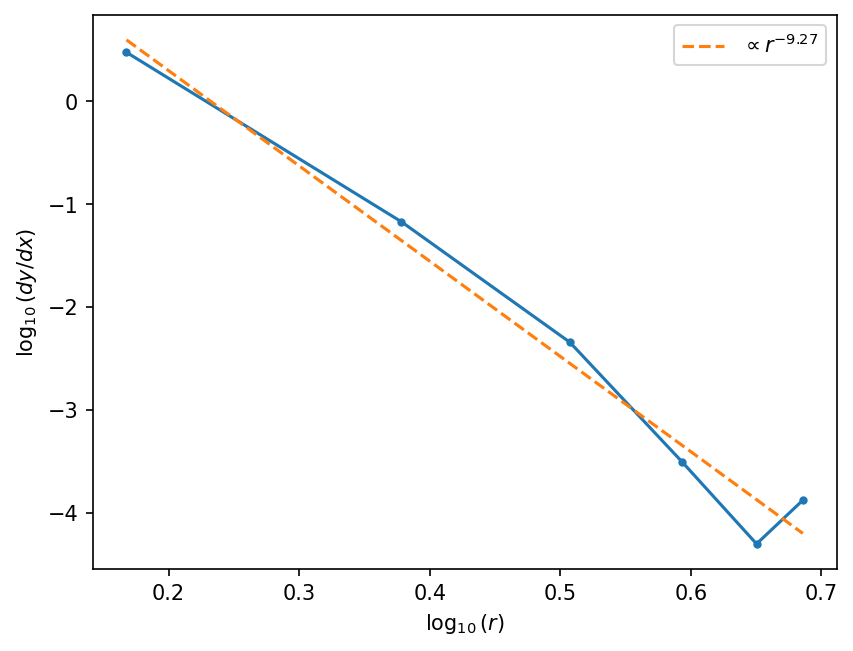

In [92]:
y = y * np.exp(8*beta)
x_mid = (x[1:] + x[:-1]) / 2
y_d = (-y[1:] + y[:-1]) / (x[1:] - x[:-1])
plt.plot(np.log10(x_mid), np.log10(y_d), '.-')
poly = np.poly1d(np.polyfit(np.log10(x_mid), np.log10(y_d), 1))
x_fit = np.linspace(min(x_mid), max(x_mid), 100)
y_fit = 10**(poly(np.log10(x_fit)))
plt.plot(np.log10(x_fit), np.log10(y_fit), '--', label=r'$\propto r^{%.2f}$' % poly.coefficients[0])
plt.xlabel(r'$\log_{10}(r)$')
plt.ylabel(r'$\log_{10}(dy/dx)$')
plt.legend()

In [57]:
print(Theory_value_list)
y = [(Theory_value_list[i+1] + Theory_value_list[i-1] - 2*Theory_value_list[i])/2 for i in range(1, len(Theory_value_list)-1)]
print([(Theory_value_list[i+1] + Theory_value_list[i-1] - 2*Theory_value_list[i])/2 for i in range(1, len(Theory_value_list)-1)])

[0.87913 0.87816 0.87814 0.87814 0.87814 0.87814 0.87814]
[np.float64(0.00047182701751236067), np.float64(9.386722224280497e-06), np.float64(5.552989377211048e-07), np.float64(2.9381861943456045e-08), np.float64(-2.5001001269231438e-09)]


  poly = np.poly1d(np.polyfit(np.log(r_chord[1:-1]), np.log(y), 1))


Intel oneMKL ERROR: Parameter 6 was incorrect on entry to DGELSD.


LinAlgError: SVD did not converge in Linear Least Squares

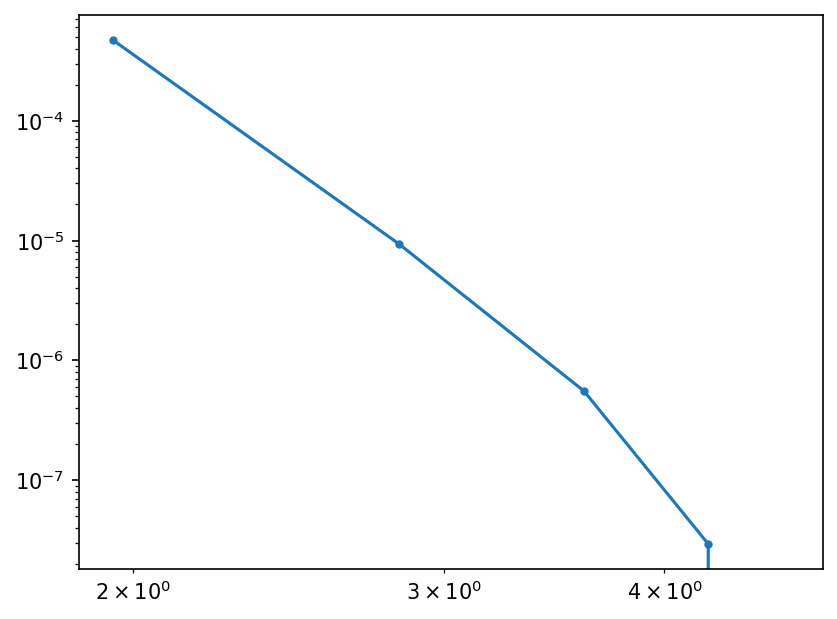

In [58]:
plt.loglog(r_chord[1:-1], y, '.-')
poly = np.poly1d(np.polyfit(np.log(r_chord[1:-1]), np.log(y), 1))
x_fit = np.linspace(min(r_chord[1:-1]), max(r_chord), 100)
y_fit = np.exp(poly(np.log(x_fit)))
plt.plot(x_fit, y_fit, '--', label=r'$\propto r^{%.2f}$' % poly.coefficients[0])
plt.xlabel(r'$r$')
plt.ylabel('Second derivative of Theory value at N->infinity')
plt.legend()

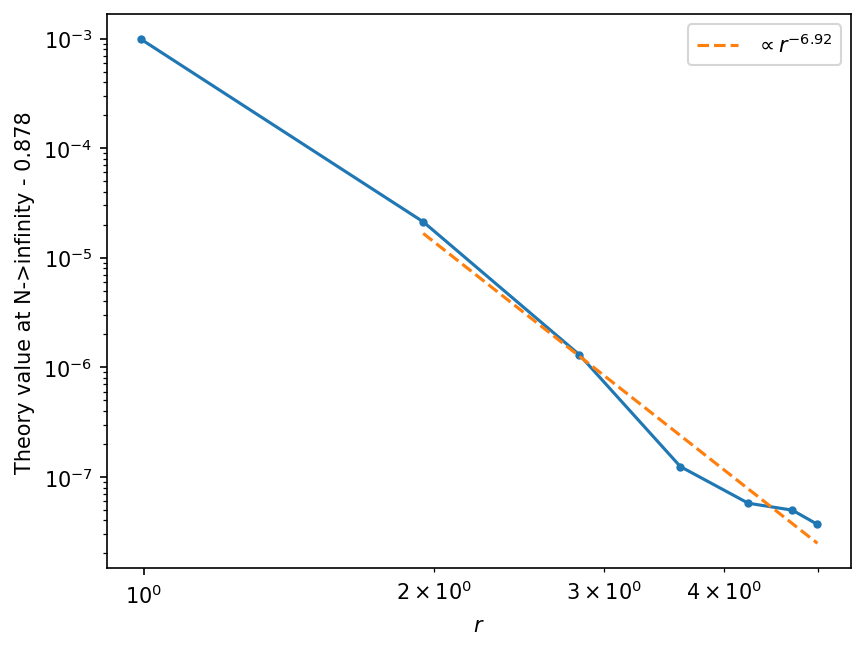

In [7]:
c = poly.coefficients[2]
plt.loglog(r_chord, Theory_value_list - c, '.-')
poly = np.poly1d(np.polyfit(np.log(r_chord[1:]), np.log(Theory_value_list[1:] - c), 1))
x_fit = np.linspace(min(r_chord[1:]), max(r_chord), 100)
y_fit = np.exp(poly(np.log(x_fit)))
plt.plot(x_fit, y_fit, '--', label=r'$\propto r^{%.2f}$' % poly.coefficients[0])
plt.xlabel(r'$r$')
plt.ylabel(f'Theory value at N->infinity - {c:.3f}')
plt.legend()    

In [1]:
from exactdiagonalization import *
from utils import weak_measurement_pauli, sZ, sX
L_list = [16] # 8, 10, 12, 14, 16, 18, 20
beta_list = [-0.1, -0.2, -0.3, -0.4, -0.5, -0.8, -1.0, -1.2, -1.5] # 0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.5, 0.8, 1.0

for L in L_list:
    wavefunction = np.load('../data/CritIsing_L'+str(L)+'_ground_state.npy')
    for beta in beta_list:
        results_z = []
        results_x = []
        for r in range(1, L//2):
            ops = [(sZ, 0), (sZ, r)]
            povm = weak_measurement_pauli(sX, beta=beta, real=True)
            povm_list = [povm] * L
            site_ind = np.arange(L)
            altered_moment = measurement_altered_moments(wavefunction, k=2, povm_list=povm_list, site_ind=site_ind, ops=ops)
            results_z.append(altered_moment)
            print(f"L = {L}, beta = {beta}: Measurement-altered Z second moment for r={r}: {altered_moment}")
            
            # ops = [(sX, 0), (sX, r)]
            # povm = weak_measurement_pauli(sX, beta=beta, real=True)
            # povm_list = [povm] * L
            # site_ind = np.arange(L)
            # altered_moment = measurement_altered_moments(wavefunction, k=2, povm_list=povm_list, site_ind=site_ind, ops=ops)
            # results_x.append(altered_moment)
            # print(f"L = {L}, beta = {beta}: Measurement-altered X second moment for r={r}: {altered_moment}")
            
        results_z = np.array(results_z)
        # results_x = np.array(results_x)
        np.save('temp/CritIsing_L'+str(L)+'_beta'+str(beta)+'_Xmeas_2ptZ_second_moment_theory.npy', results_z)
        # np.save('temp/CritIsing_L'+str(L)+'_beta'+str(beta)+'_X_2pt_second_moment_theory.npy', results_x)

L = 16, beta = -0.1: Measurement-altered Z second moment for r=1: 0.3877744550036296
L = 16, beta = -0.1: Measurement-altered Z second moment for r=2: 0.282906856212161
L = 16, beta = -0.1: Measurement-altered Z second moment for r=3: 0.2359610513682478
L = 16, beta = -0.1: Measurement-altered Z second moment for r=4: 0.20954576408323408
L = 16, beta = -0.1: Measurement-altered Z second moment for r=5: 0.19341064407260708
L = 16, beta = -0.1: Measurement-altered Z second moment for r=6: 0.18356605088676495
L = 16, beta = -0.1: Measurement-altered Z second moment for r=7: 0.1782007279192996
L = 16, beta = -0.2: Measurement-altered Z second moment for r=1: 0.33495939422474347
L = 16, beta = -0.2: Measurement-altered Z second moment for r=2: 0.24642931151373787
L = 16, beta = -0.2: Measurement-altered Z second moment for r=3: 0.20613397390190238


KeyboardInterrupt: 

In [3]:
import matplotlib.pyplot as plt
import MPSToolBox as my
import numpy as np

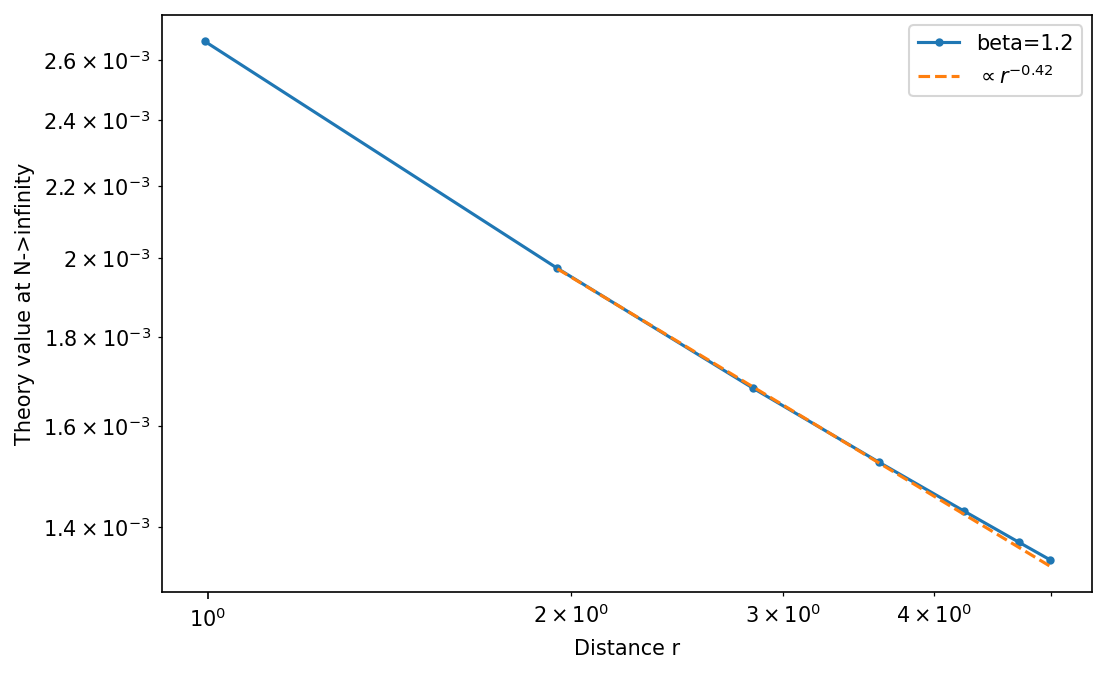

In [10]:
plt.figure(figsize=(8,5))
L = 16
r_list = np.arange(1, L//2)
r_chord = my.chord(r_list, L)
for beta in [1.2]:
    Theory_value_list = np.load(f"temp/CritIsing_L{L}_beta{beta}_Xmeas_2ptZ_second_moment_theory.npy")
    plt.plot(r_chord, Theory_value_list, '.-', label=f'beta={beta}')
    k_, b_ = np.polyfit(np.log(r_chord[1:4]), np.log(Theory_value_list[1:4]), 1)
    x_fit = np.linspace(min(r_chord[1:4]), max(r_chord), 100)
    y_fit = np.exp(k_ * np.log(x_fit) + b_)
    plt.plot(x_fit, y_fit, '--', label=r'$\propto r^{%.2f}$' % k_)
plt.xlabel('Distance r')
plt.ylabel('Theory value at N->infinity')
plt.legend()
plt.xscale('log')
plt.yscale('log')

# Measure x, probe ZZ?